# Prioritising Garda stations for operational focus using long-term crime trends (2015–2024)


In [1]:
# Imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

## Executive Summary

**Stakeholder**: Garda divisional operations planner.  
**Core decision**: Which stations to prioritise for additional attention or resources over the next 3–5 years?  
**Key KPIs**:  
- Recent incident volume (2020–2024).  
- Growth vs historical baseline (2015–2019).  
- Composite Risk Index (balancing workload and growth).  

This analysis shows crime workload is highly concentrated in a small number of stations (top 20 account for ~35% of national incidents), with Dublin dominating but several non-Dublin stations also ranking high due to growth. The Risk Index ranking can directly inform resource allocation discussions.

**TL;DR**:  
- Recorded crime structurally concentrated in theft, road/traffic, public order.  
- Top stations: Store Street, Pearse Street, Blanchardstown (Dublin); Waterford, Nenagh, Drogheda (non-Dublin).  
- Risk framework ready for dashboards or planning meetings.


In [2]:
# Load structured crime data from file 1
crime_path = "ireland_crime_structured_dataset.csv"
df = pd.read_csv(crime_path)

print('Data imported successfully.')

Data imported successfully.


In [3]:
df.head()

,year,station_code,station_name,station_division,offence_group_code,offence_group_name,incidents
0,2003,35301,Abbeyfeale,Limerick,3,"Attempts/threats to murder, assaults, harassme...",18
1,2003,35301,Abbeyfeale,Limerick,4,Dangerous or negligent acts,27
2,2003,35301,Abbeyfeale,Limerick,5,Kidnapping and related offences,0
3,2003,35301,Abbeyfeale,Limerick,6,"Robbery, extortion and hijacking offences",0
4,2003,35301,Abbeyfeale,Limerick,7,Burglary and related offences,27


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173712 entries, 0 to 173711
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   year                173712 non-null  int64 
 1   station_code        173712 non-null  int64 
 2   station_name        173712 non-null  object
 3   station_division    173712 non-null  object
 4   offence_group_code  173712 non-null  int64 
 5   offence_group_name  173712 non-null  object
 6   incidents           173712 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 9.3+ MB


In [5]:
df.shape

(173712, 7)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# unique station names
unique_stations = df['station_name'].nunique()

print('Total Garda Stations : ', unique_stations)

Total Garda Stations :  560


In [8]:
unique_station_codes = df['station_code'].nunique()

print('Total Garda Stations Codes : ', unique_station_codes)

Total Garda Stations Codes :  564


In [9]:
station_code_discrepancy = df.groupby('station_name')['station_code'].nunique()
discrepant_names = station_code_discrepancy[station_code_discrepancy > 1]

print("Station names with more than one unique station code:")
print(discrepant_names)

print(f"\nNumber of unique station names: {df['station_name'].nunique()}")
print(f"Number of unique station codes: {df['station_code'].nunique()}")
print(f"Difference: {df['station_code'].nunique() - df['station_name'].nunique()}")

Station names with more than one unique station code:
station_name
Blackrock    3
Milford      2
Newport      2
Name: station_code, dtype: int64

Number of unique station names: 560
Number of unique station codes: 564
Difference: 4


In [10]:
discrepant_station_data = df[df['station_name'].isin(discrepant_names.index)][['station_name', 'station_code']].drop_duplicates().sort_values(by='station_name')
display(discrepant_station_data)

,station_name,station_code
1498,Blackrock,31104
1512,Blackrock,65101
1526,Blackrock,14301
5586,Milford,32307
5600,Milford,12408
6146,Newport,22605
6160,Newport,51308


Blackrock, Milford and Newport each appear multiple times in the Garda datasets because the “station code” you are seeing is not a single unique ID per placename, but per individual station record, and there are multiple Garda stations with the same town name in different counties or regions.

Blackrock – 3 codes
There are at least three different Garda stations named Blackrock:

Blackrock, Dublin (Dublin Metropolitan Region – DMR East).

Blackrock, Cork City.
​

Blackrock, Co. Louth (near Dundalk).
​

Each of these appears as a separate record in the official station list / GIS KML with its own internal ID or “code,” so when you group by just the word “Blackrock” you see three codes.

Milford – 2 codes
“Milford” exists as:

Milford, Co. Donegal.
​

Milford, Co. Cork.
​

Again, these are distinct stations in different divisions, so each has its own station code, giving two codes for the placename Milford.

Newport – 2 codes
“Newport” has at least:

Newport, Co. Tipperary.
​

Newport, Co. Mayo.
​

These are different Garda stations in different counties/divisions, so they are coded separately, which is why you see two station codes attached to the name Newport.

In [11]:
station_division_count = df['station_division'].nunique()

print('Total unique station divisions : ', station_division_count)

Total unique station divisions :  41


In [12]:
offence_group_codes = df['offence_group_code'].nunique()

print('Total unique offence group codes : ', offence_group_codes)

Total unique offence group codes :  14


In [13]:
offence_group_names = df['offence_group_name'].nunique()

print('Total unique offence group names : ', offence_group_names)

Total unique offence group names :  14


In [14]:
station_division_names = df['station_division'].value_counts()

print(station_division_names)

station_division
Galway                       14168
Donegal                      11088
Tipperary                    10780
Cork West                     9240
Limerick                      8932
Mayo                          8624
Kilkenny/Carlow               7700
Cavan/Monaghan                7700
Laois/Offaly                  7392
Kerry                         7392
Cork North                    7084
Roscommon/Longford            6776
Wexford                       6776
Sligo/Leitrim                 5544
Wicklow                       5236
Waterford                     5236
Clare                         5236
Meath                         4928
Cork City                     4620
Kildare                       4620
D.M.R. Northern               4004
Westmeath                     4004
Louth                         3696
D.M.R. Western                2464
D.M.R. Southern               1848
D.M.R. South Central          1540
D.M.R. Eastern                1232
D.M.R. North Central          1232
Co 

In [15]:
division_to_county = {
    # Single-county divisions
    "Galway": "Galway",
    "Donegal": "Donegal",
    "Tipperary": "Tipperary",
    "Cork West": "Cork",
    "Limerick": "Limerick",
    "Mayo": "Mayo",
    "Kilkenny/Carlow": "Kilkenny/Carlow",
    "Cavan/Monaghan": "Cavan/Monaghan",
    "Laois/Offaly": "Laois/Offaly",
    "Kerry": "Kerry",
    "Cork North": "Cork",
    "Roscommon/Longford": "Roscommon/Longford",
    "Wexford": "Wexford",
    "Sligo/Leitrim": "Sligo/Leitrim",
    "Wicklow": "Wicklow",
    "Waterford": "Waterford",
    "Clare": "Clare",
    "Meath": "Meath",
    "Cork City": "Cork",
    "Kildare": "Kildare",
    "Louth": "Louth",
    "Westmeath": "Westmeath",

    # Dublin Metropolitan Region – all are Dublin
    "D.M.R. Northern": "Dublin",
    "D.M.R. Western": "Dublin",
    "D.M.R. Southern": "Dublin",
    "D.M.R. South Central": "Dublin",
    "D.M.R. Eastern": "Dublin",
    "D.M.R. North Central": "Dublin",

    # “Co X, Division” variants – map to the county
    "Co Waterford, Waterford": "Waterford",
    "Co Cork, Cork North": "Cork",
    "Co. Kerry, Kerry": "Kerry",
    "Co Louth, Louth": "Louth",
    "Co Cork, Cork City": "Cork",
    "Co. Tipperary, Tipperary": "Tipperary",
    "Co. Offaly, Laois/Offaly": "Laois/Offaly",
    "Co Dublin, D.M.R. Eastern": "Dublin",
    "Co Donegal, Donegal": "Donegal",
    "Co. Cork, Cork West": "Cork",
    "Co Mayo, Mayo": "Mayo",
    "Co Tipperary, Tipperary": "Tipperary",
    "Co Kerry, Cork West": "Kerry",
}


In [16]:
df["county"] = df["station_division"].map(division_to_county)

print(df["county"].value_counts(dropna=False))

county
Cork                  22176
Galway                14168
Dublin                12628
Donegal               11396
Tipperary             11396
Limerick               8932
Mayo                   8932
Kerry                  8008
Laois/Offaly           7700
Cavan/Monaghan         7700
Kilkenny/Carlow        7700
Wexford                6776
Roscommon/Longford     6776
Waterford              5852
Sligo/Leitrim          5544
Wicklow                5236
Clare                  5236
Meath                  4928
Kildare                4620
Louth                  4004
Westmeath              4004
Name: count, dtype: int64


### County vs division caveat

Although Ireland has 26 counties, the Garda crime data is organised by **Garda divisions**, not pure counties. Several divisions span two counties (for example, *Laois/Offaly*, *Kilkenny/Carlow*, *Roscommon/Longford*, *Cavan/Monaghan*, *Sligo/Leitrim*), and Dublin is represented through multiple Dublin Metropolitan Region (D.M.R.) divisions rather than a single “Dublin” label. As a result, when deriving a `county` field from `station_division`, the dataset contains 21 distinct division‑based county values rather than 26 standalone counties, and the analysis treats these combined divisions as single analytical units.


In [17]:
df.head()

,year,station_code,station_name,station_division,offence_group_code,offence_group_name,incidents,county
0,2003,35301,Abbeyfeale,Limerick,3,"Attempts/threats to murder, assaults, harassme...",18,Limerick
1,2003,35301,Abbeyfeale,Limerick,4,Dangerous or negligent acts,27,Limerick
2,2003,35301,Abbeyfeale,Limerick,5,Kidnapping and related offences,0,Limerick
3,2003,35301,Abbeyfeale,Limerick,6,"Robbery, extortion and hijacking offences",0,Limerick
4,2003,35301,Abbeyfeale,Limerick,7,Burglary and related offences,27,Limerick


In [18]:
df = df[[
    "year",
    "station_code",
    "station_name",
    "station_division",
    "county",
    "offence_group_code",
    "offence_group_name",
    "incidents"
]]

In [19]:
df.head()

,year,station_code,station_name,station_division,county,offence_group_code,offence_group_name,incidents
0,2003,35301,Abbeyfeale,Limerick,Limerick,3,"Attempts/threats to murder, assaults, harassme...",18
1,2003,35301,Abbeyfeale,Limerick,Limerick,4,Dangerous or negligent acts,27
2,2003,35301,Abbeyfeale,Limerick,Limerick,5,Kidnapping and related offences,0
3,2003,35301,Abbeyfeale,Limerick,Limerick,6,"Robbery, extortion and hijacking offences",0
4,2003,35301,Abbeyfeale,Limerick,Limerick,7,Burglary and related offences,27


Years: 2003 to 2024
Stations: 564
Offence groups: 14
Divisions: 41


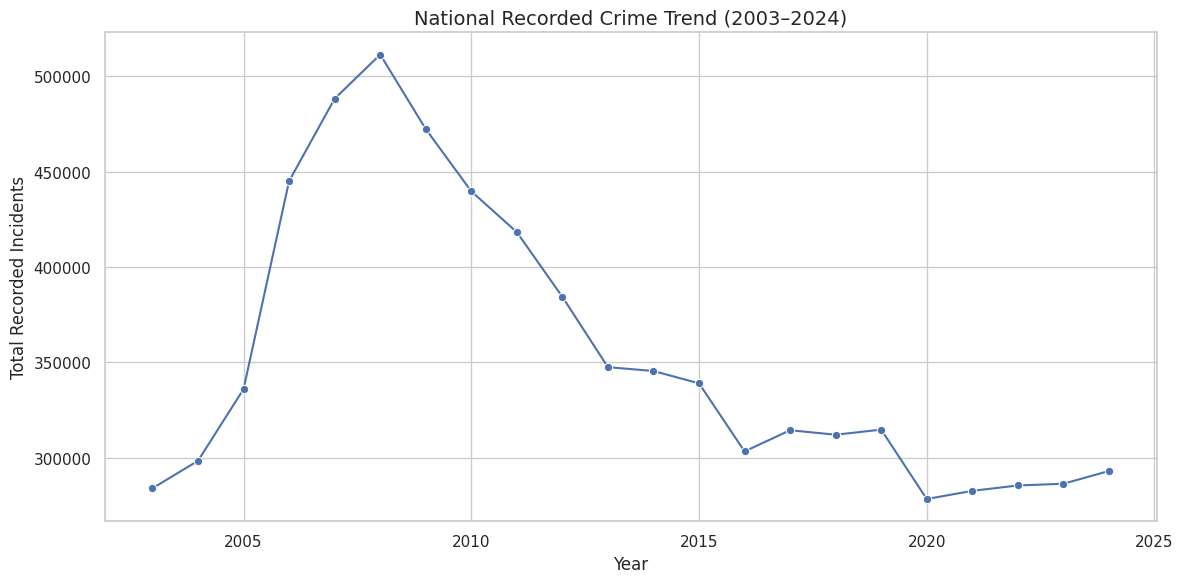

In [20]:
print("Years:", df["year"].min(), "to", df["year"].max())
print("Stations:", df["station_code"].nunique())
print("Offence groups:", df["offence_group_code"].nunique())
print("Divisions:", df["station_division"].nunique())

# Simple helper for nicer plots
sns.set(style="whitegrid")

# Plotting total incidents over the years

incidents_by_year = (df.groupby("year", as_index=False)["incidents"].sum().sort_values("year"))

plt.figure(figsize=(12, 6))
sns.lineplot(data=incidents_by_year,x="year",y="incidents",marker="o")
plt.title("National Recorded Crime Trend (2003–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total Recorded Incidents")
plt.tight_layout()
plt.show()

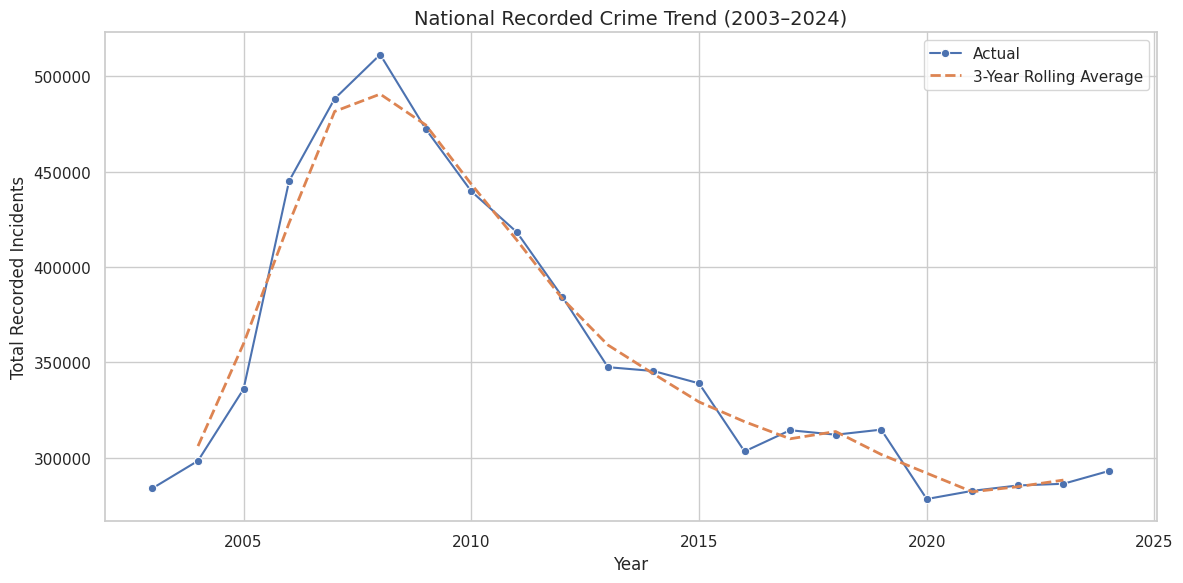

In [21]:
# National Recorded Crime Trend (Actual + 3-Year Rolling Average)

sns.set(style="whitegrid")

# Calculate rolling average
incidents_by_year["rolling_3yr_avg"] = (incidents_by_year["incidents"].rolling(window=3, center=True).mean())
plt.figure(figsize=(12, 6))
sns.lineplot(data=incidents_by_year, x="year", y="incidents", marker="o", label="Actual")
sns.lineplot(data=incidents_by_year, x="year", y="rolling_3yr_avg", linestyle="--", linewidth=2, label="3-Year Rolling Average")
plt.title("National Recorded Crime Trend (2003–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total Recorded Incidents")
plt.legend()
plt.tight_layout()
plt.show()

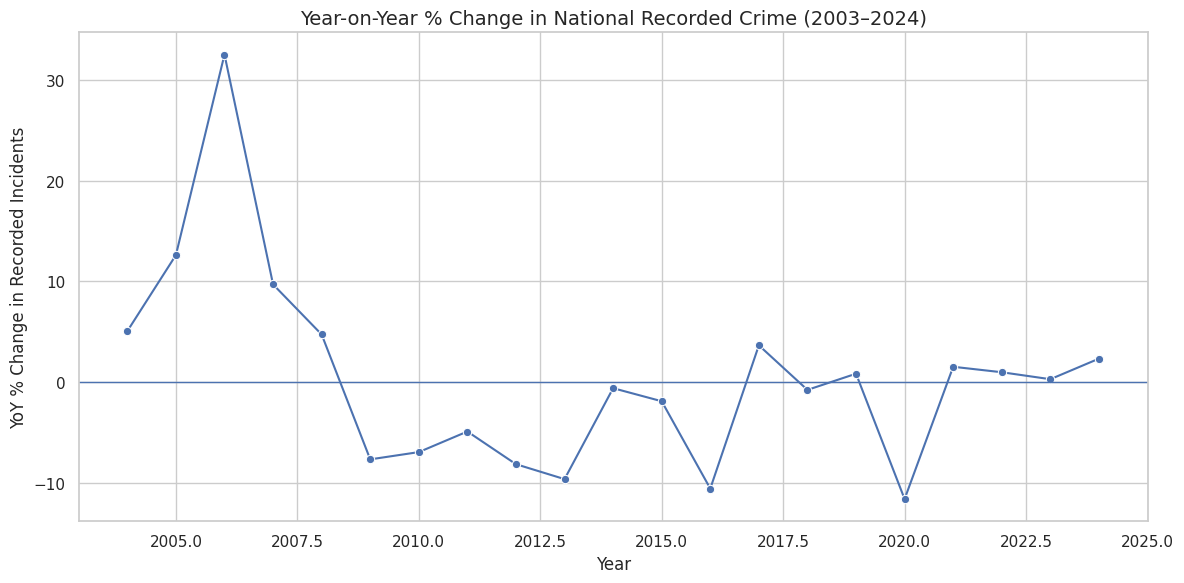

In [22]:
# Year-on-year % change in national recorded incidents

incidents_by_year["pct_change"] = incidents_by_year["incidents"].pct_change() * 100

plt.figure(figsize=(12, 6))
sns.lineplot(data=incidents_by_year, x="year", y="pct_change", marker="o")
plt.title("Year-on-Year % Change in National Recorded Crime (2003–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("YoY % Change in Recorded Incidents")
plt.axhline(0, linewidth=1)   # reference line: growth vs decline
plt.tight_layout()
plt.show()

Over the period of 2003-2024, the number of recorded incidents at the national level increases substantially to a peak in the late 2000s and then persists in a multi-year decline, followed by a stabilisation in the mid-to-late 2010s. The rolling average makes it clear that this is a structural change and not just random fluctuations from year to year. The series of year-over-year percentage change reveals that the biggest fluctuations are to be found in the early years, while the latter years are much more stable, except for a clear disruption around 2020 (as would be expected during a period of major external shock), followed by a gradual recovery in the following years.

In [23]:
# Aggregate total incidents by offence group (all years combined)
offence_totals = (
    df.groupby("offence_group_name", as_index=False)["incidents"]
      .sum()
      .sort_values("incidents", ascending=False)
)

# Preview top 10 offence groups
print("Top 10 offence groups by total recorded incidents:")
display(offence_totals.head(10))

Top 10 offence groups by total recorded incidents:


,offence_group_name,incidents
10,Road and traffic offences,1880513
12,Theft and related offences,1566268
9,Public order and other social code offences,924455
4,Dangerous or negligent acts,915139
3,Damage to property and to the environment off...,665813
1,Burglary and related offences,461603
0,"Attempts/threats to murder, assaults, harassme...",400061
2,Controlled drug offences,376566
7,"Offences against government, justice procedure...",258971
5,"Fraud, deception and related offences",148967


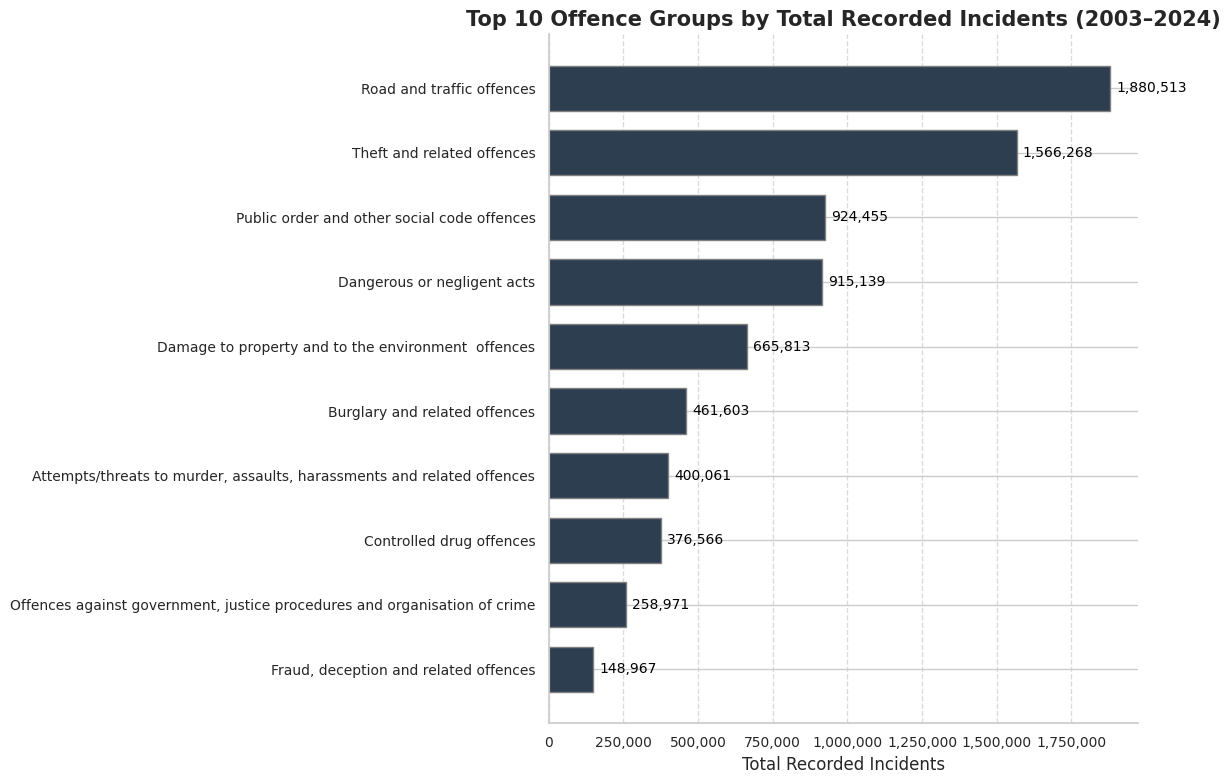

In [24]:
top10_offences = offence_totals.head(10).copy()

# Reverse order for better readability (largest on top)
top10_offences = top10_offences.sort_values("incidents", ascending=True)
plt.figure(figsize=(12, 8))
bars = plt.barh(
    top10_offences["offence_group_name"],
    top10_offences["incidents"],
    color="#2C3E50",
    edgecolor="grey",
    height=0.7
)

plt.title("Top 10 Offence Groups by Total Recorded Incidents (2003–2024)",fontsize=15,weight='bold')
plt.xlabel("Total Recorded Incidents", fontsize=12)
plt.ylabel("")

# Format numbers with commas
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add data labels at end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01 * plt.xlim()[1],
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        ha="left",
        fontsize=10,
        color="black"
    )

# Remove top and right spines
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

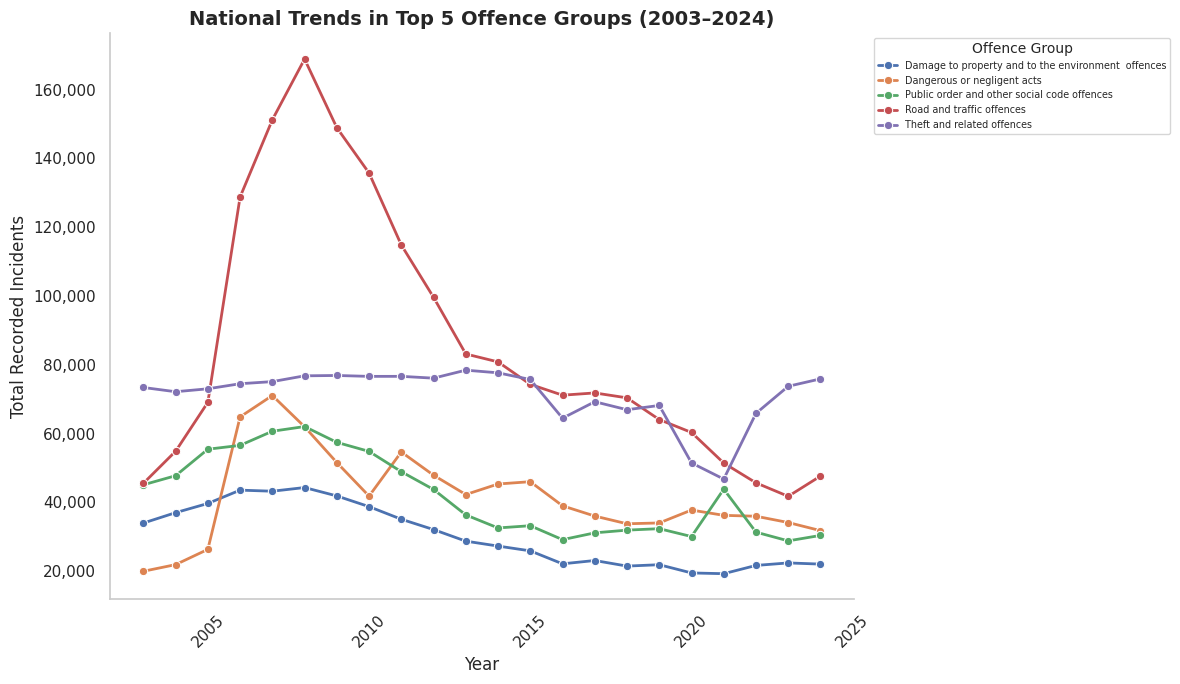

In [25]:
# Top 5 Offence Groups Over Time

# Select top 5 offence groups
top_groups = offence_totals["offence_group_name"].head(5).tolist()

offence_year = (
    df[df["offence_group_name"].isin(top_groups)]
      .groupby(["year", "offence_group_name"], as_index=False)["incidents"]
      .sum()
      .sort_values("year")
)

plt.figure(figsize=(12, 7))
sns.lineplot(data=offence_year, x="year", y="incidents", hue="offence_group_name", marker="o", linewidth=2)
plt.title("National Trends in Top 5 Offence Groups (2003–2024)", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Total Recorded Incidents")

# Format large numbers
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.xticks(rotation=45)

# Remove top/right spines for cleaner look
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.grid(False)

# Adjust legend font sizes
plt.legend(title="Offence Group", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize='xx-small', title_fontsize='small')

plt.tight_layout()
plt.show()

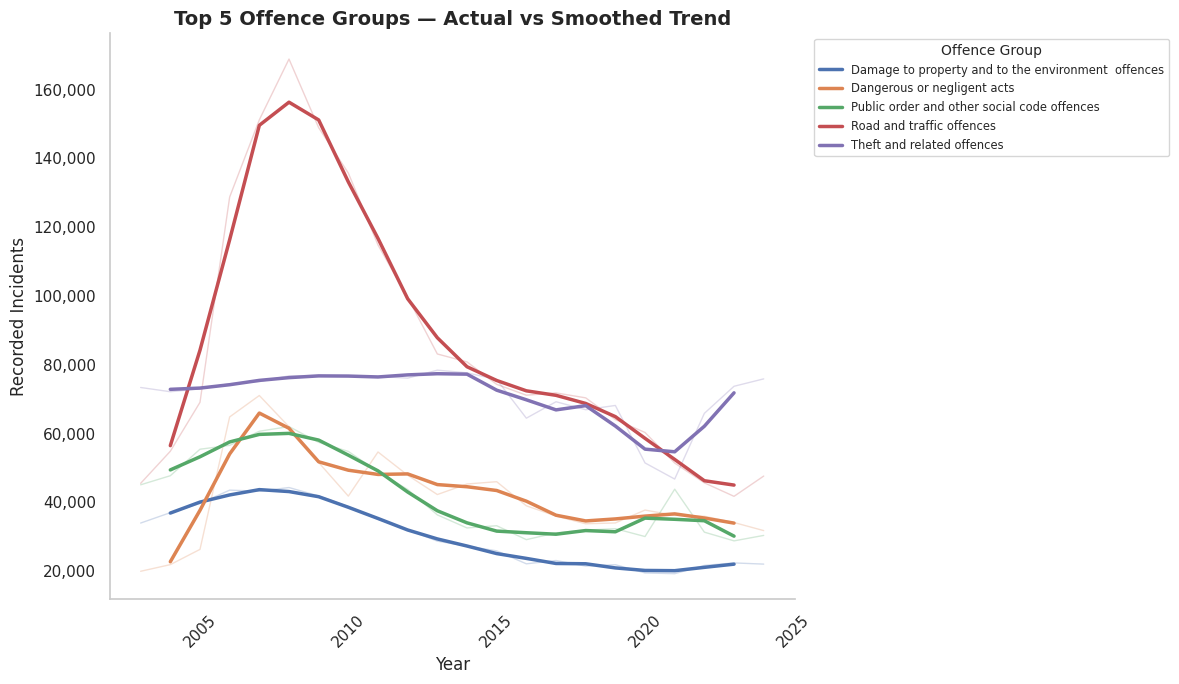

In [26]:
# Actual vs Smoothed: Top 5 Offence Groups (clean overlay)

import matplotlib.ticker as ticker

top_groups = offence_totals["offence_group_name"].head(5).tolist()

offence_year = (
    df[df["offence_group_name"].isin(top_groups)]
      .groupby(["year", "offence_group_name"], as_index=False)["incidents"]
      .sum()
      .sort_values("year")
)

offence_year["rolling_3yr_avg"] = (
    offence_year.groupby("offence_group_name")["incidents"]
                .transform(lambda x: x.rolling(3, center=True).mean())
)

plt.figure(figsize=(12, 7))

# Actual (lighter / thinner)
sns.lineplot(
    data=offence_year,
    x="year",
    y="incidents",
    hue="offence_group_name",
    linewidth=1,
    alpha=0.25,
    legend=False
)

# Smoothed (bold)
sns.lineplot(
    data=offence_year,
    x="year",
    y="rolling_3yr_avg",
    hue="offence_group_name",
    linewidth=2.5
)

plt.title("Top 5 Offence Groups — Actual vs Smoothed Trend", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Recorded Incidents")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)

plt.xticks(rotation=45)
plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(title="Offence Group", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize='x-small', title_fontsize='small')
plt.tight_layout()
plt.show()

In [27]:
# Offence-group concentration (share of national incidents)

total_incidents = offence_totals["incidents"].sum()

offence_totals = offence_totals.copy()
offence_totals["share_pct"] = offence_totals["incidents"] / total_incidents * 100
offence_totals["cumulative_share_pct"] = offence_totals["share_pct"].cumsum()

# Quick concentration summary
top5_share = offence_totals.head(5)["share_pct"].sum()
top10_share = offence_totals.head(10)["share_pct"].sum()

print(f"Top 5 offence groups account for {top5_share:.1f}% of all recorded incidents. \n")
print(f"Top 10 offence groups account for {top10_share:.1f}% of all recorded incidents. \n")

display(offence_totals.head(10))

Top 5 offence groups account for 76.5% of all recorded incidents. 

Top 10 offence groups account for 97.7% of all recorded incidents. 



,offence_group_name,incidents,share_pct,cumulative_share_pct
10,Road and traffic offences,1880513,24.172737,24.172737
12,Theft and related offences,1566268,20.133328,44.306065
9,Public order and other social code offences,924455,11.883251,56.189316
4,Dangerous or negligent acts,915139,11.763500,67.952815
3,Damage to property and to the environment off...,665813,8.558581,76.511396
1,Burglary and related offences,461603,5.933598,82.444994
0,"Attempts/threats to murder, assaults, harassme...",400061,5.142517,87.587511
2,Controlled drug offences,376566,4.840504,92.428015
7,"Offences against government, justice procedure...",258971,3.328899,95.756914
5,"Fraud, deception and related offences",148967,1.914871,97.671785


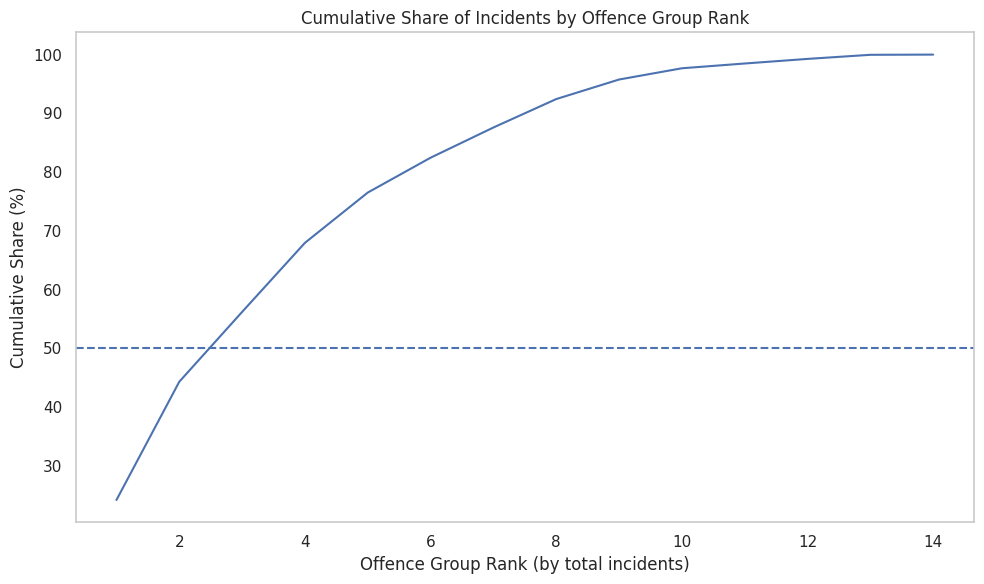

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(offence_totals) + 1), offence_totals["cumulative_share_pct"])
plt.axhline(50, linestyle="--")
plt.title("Cumulative Share of Incidents by Offence Group Rank")
plt.xlabel("Offence Group Rank (by total incidents)")
plt.ylabel("Cumulative Share (%)")
plt.grid(False)
plt.tight_layout()
plt.show()

Nationally, recorded crime is structurally concentrated in a small number of offence groups. Road and traffic offences and theft-related offences account for the largest cumulative volumes over 2003–2024, followed by public order and dangerous or negligent acts.

Concentration analysis shows that the top five offence groups account for approximately 76.5% of all recorded incidents, while the top ten groups account for 97.7% of total volume. Whereas, top 3 offence groups holds 50% of the total incidents. This confirms that national crime burden is heavily skewed toward a limited set of offence categories rather than being evenly distributed across all classifications.

Trend analysis of the top five categories shows a pronounced peak in the late 2000s followed by a sustained decline across most groups. Theft-related offences remain relatively persistent over time, while other categories exhibit cyclical movement. The 3-year rolling averages confirm these patterns reflect longer-term structural shifts rather than short-term volatility.

These offence concentration dynamics provide important structural context before transitioning to station-level risk scoring, where we assess whether this burden is similarly concentrated geographically across divisions and stations.

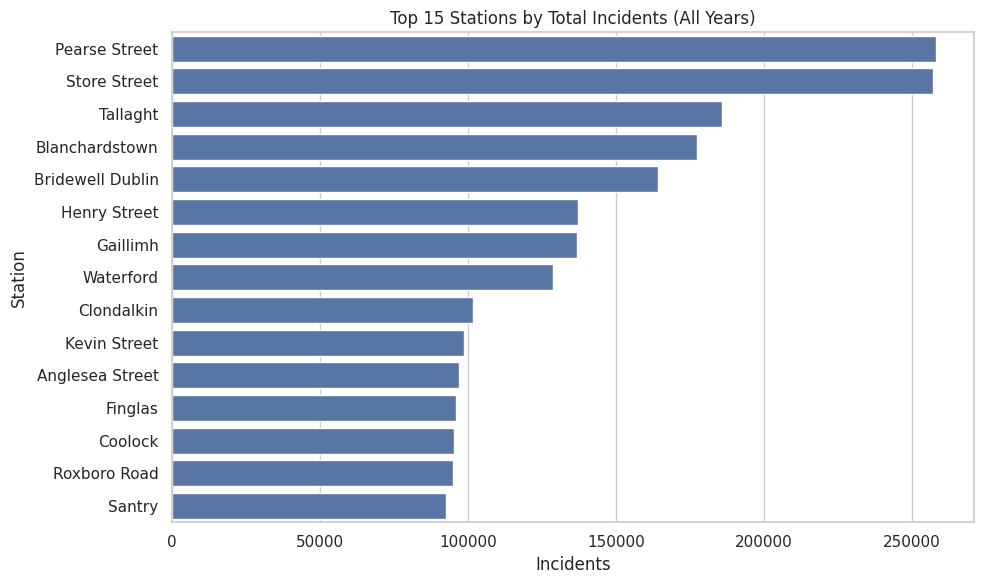

In [29]:
# Total incidents by station (all years)
station_totals = (
    df.groupby(["station_code", "station_name", "station_division"], as_index=False)["incidents"]
      .sum()
      .sort_values("incidents", ascending=False)
)

station_totals.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=station_totals.head(15),
            x="incidents", y="station_name",
            order=station_totals.head(15)["station_name"])
plt.title("Top 15 Stations by Total Incidents (All Years)")
plt.xlabel("Incidents")
plt.ylabel("Station")
plt.tight_layout()
plt.show()


In [30]:
# Total national incidents
total_national = station_totals["incidents"].sum()

# Compute share and cumulative share
station_totals["share_pct"] = station_totals["incidents"] / total_national * 100
station_totals["cumulative_share_pct"] = station_totals["share_pct"].cumsum()

station_totals.head(10)

,station_code,station_name,station_division,incidents,share_pct,cumulative_share_pct
524,61202,Pearse Street,D.M.R. South Central,258096,3.317651,3.317651
530,62301,Store Street,D.M.R. North Central,257130,3.305234,6.622886
547,64202,Tallaght,D.M.R. Southern,185904,2.389672,9.012557
555,66101,Blanchardstown,D.M.R. Western,177488,2.281490,11.294047
527,62101,Bridewell Dublin,D.M.R. North Central,164239,2.111183,13.405229
315,35203,Henry Street,Limerick,137085,1.762136,15.167365
155,23304,Gaillimh,Galway,136959,1.760516,16.927882
521,54304,Waterford,Waterford,128771,1.655265,18.583147
559,66202,Clondalkin,D.M.R. Western,101880,1.309599,19.892746
525,61301,Kevin Street,D.M.R. South Central,98747,1.269327,21.162073


In [31]:
top10_share = station_totals.head(10)["share_pct"].sum()
top20_share = station_totals.head(20)["share_pct"].sum()
top50_share = station_totals.head(50)["share_pct"].sum()

print(f"Top 10 stations account for {top10_share:.1f}% of all recorded incidents.")
print(f"Top 20 stations account for {top20_share:.1f}% of all recorded incidents.")
print(f"Top 50 stations account for {top50_share:.1f}% of all recorded incidents.")


Top 10 stations account for 21.2% of all recorded incidents.
Top 20 stations account for 32.6% of all recorded incidents.
Top 50 stations account for 56.6% of all recorded incidents.


In [32]:
station_totals["rank"] = range(1, len(station_totals) + 1)

stations_50pct = station_totals[station_totals["cumulative_share_pct"] <= 50].shape[0]

print(f"{stations_50pct} stations together account for at least 50% of total recorded incidents.")

39 stations together account for at least 50% of total recorded incidents.


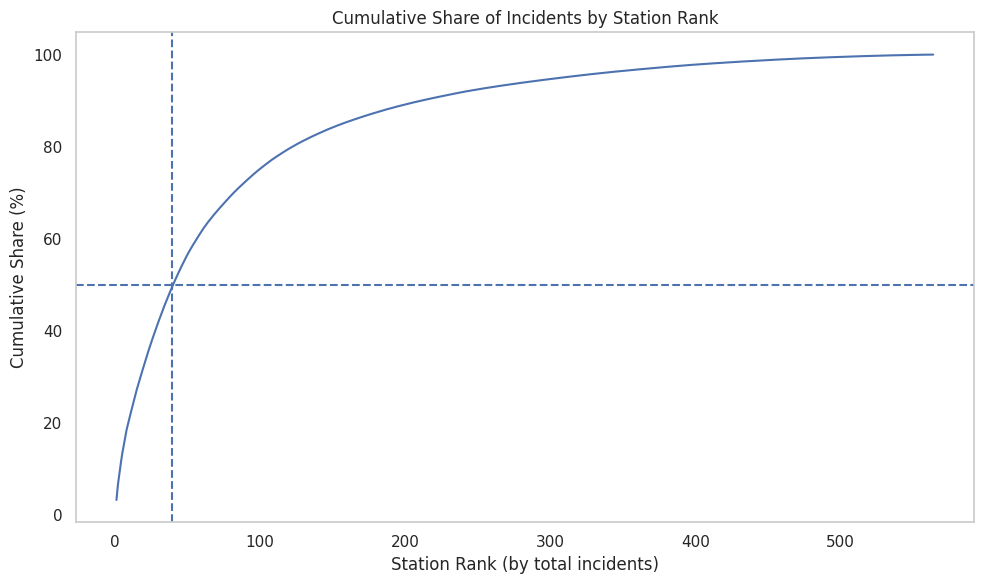

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(station_totals) + 1),
    station_totals["cumulative_share_pct"]
)

plt.axhline(50, linestyle="--")
plt.axvline(stations_50pct, linestyle="--")
plt.title("Cumulative Share of Incidents by Station Rank")
plt.xlabel("Station Rank (by total incidents)")
plt.ylabel("Cumulative Share (%)")

plt.grid(False)
plt.tight_layout()
plt.show()

Looking across every year, it becomes evident that crime clusters heavily around just a few locations. Pearse Street along with Store Street stand out with the most reported events countrywide, then come Tallaght and Blanchardstown. Among these leading spots, many sit inside the Dublin Metropolitan Region - pointing toward cities playing a central role. The pattern holds even when spreading data wide: only a handful of stations carry the bulk.

A sharp climb in the early part of the cumulative share curve highlights uneven concentration. As rank increases, growth slows fast - evidence that only a few locations dominate incident totals. Most crimes cluster within limited points across the network. High-load sites, though few, absorb much of the overall burden.

This setup helps guide choices, because where traffic stacks up becomes obvious - shaping how support is assigned. When certain hubs handle far more activity, they stand out naturally, influencing where effort lands.

In [34]:
df['station_division'].value_counts()

,count
station_division,
Galway,14168
Donegal,11088
Tipperary,10780
Cork West,9240
Limerick,8932
Mayo,8624
Kilkenny/Carlow,7700
Cavan/Monaghan,7700
Laois/Offaly,7392


Before aggregating incidents at division level, station_division labels were standardised to remove structural naming variants (e.g., “Co Cork, Cork North” mapped to “Cork North”). These variants represent the same operational Garda divisions but appear with different prefixes in the raw dataset.

Normalising division names ensures that incident totals are not artificially split across duplicate labels, allowing for accurate division-level concentration and share analysis.

In [35]:
# Normalise station_division labels
df["station_division"] = df["station_division"].replace({
    "Co Cork, Cork North": "Cork North",
    "Co Cork, Cork West": "Cork West",
    "Co. Cork, Cork West": "Cork West",
    "Co Cork, Cork City": "Cork City",
    "Co Waterford, Waterford": "Waterford",
    "Co Donegal, Donegal": "Donegal",
    "Co Mayo, Mayo": "Mayo",
    "Co Louth, Louth": "Louth",
    "Co. Tipperary, Tipperary": "Tipperary",
    "Co Tipperary, Tipperary": "Tipperary",
    "Co. Kerry, Kerry": "Kerry",
    "Co Kerry, Cork West": "Cork West",
    "Co. Offaly, Laois/Offaly": "Laois/Offaly",
    "Co Dublin, D.M.R. Eastern": "D.M.R. Eastern",
})

In [36]:
print(df["station_division"].nunique())
print(df["station_division"].value_counts().head(30))

28
station_division
Galway                  14168
Donegal                 11396
Tipperary               11396
Cork West                9856
Mayo                     8932
Limerick                 8932
Cavan/Monaghan           7700
Laois/Offaly             7700
Cork North               7700
Kilkenny/Carlow          7700
Kerry                    7700
Wexford                  6776
Roscommon/Longford       6776
Waterford                5852
Sligo/Leitrim            5544
Wicklow                  5236
Clare                    5236
Cork City                4928
Meath                    4928
Kildare                  4620
Louth                    4004
Westmeath                4004
D.M.R. Northern          4004
D.M.R. Western           2464
D.M.R. Southern          1848
D.M.R. Eastern           1540
D.M.R. South Central     1540
D.M.R. North Central     1232
Name: count, dtype: int64


This count actually matches with the 28 Garda divisions we had. An Garda Síochána is organised into 28 Garda Divisions, grouped under four regions following the 2019 restructuring. Dublin Metropolitan Region (DMR) - 4, Eastern Region - 9, Southern Region - 6, North Western Region - 9

,station_division,incidents
0,D.M.R. Western,662564
1,D.M.R. Northern,566084
2,D.M.R. North Central,560394
3,D.M.R. South Central,538306
4,D.M.R. Southern,453981
5,Cork City,447017
6,Limerick,432494
7,Galway,321921
8,Kildare,291815
9,D.M.R. Eastern,285950


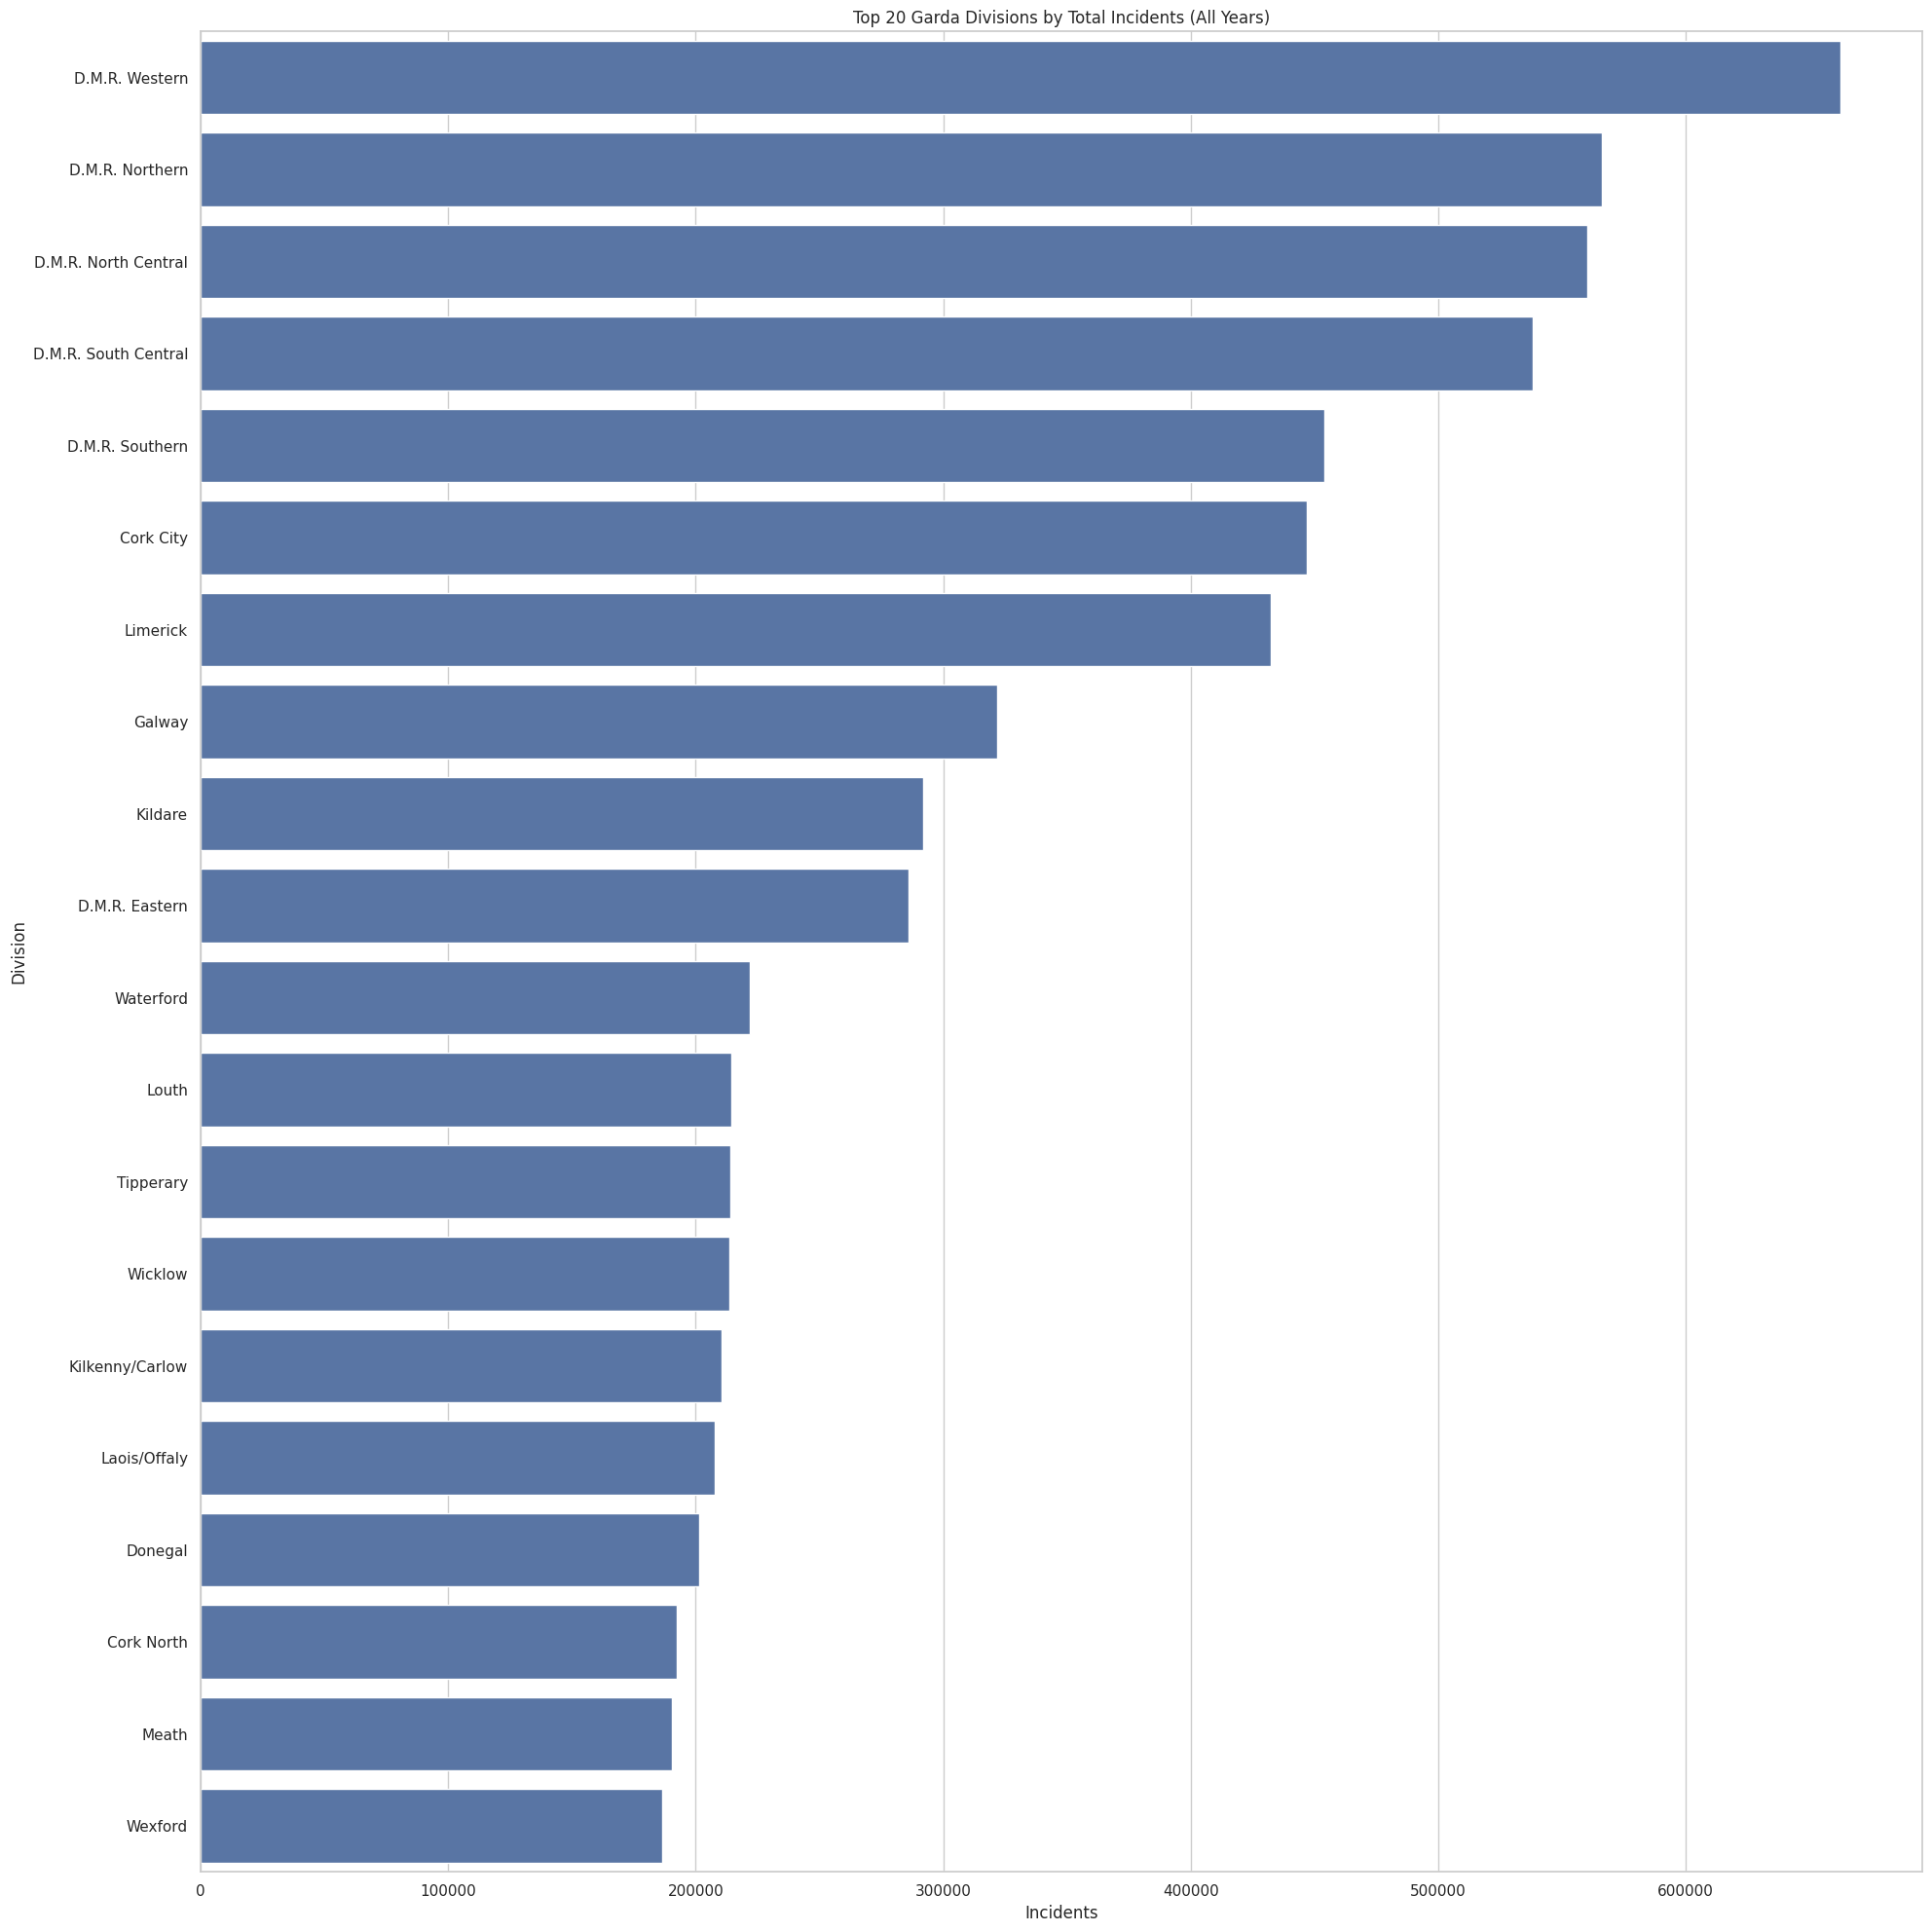

In [37]:
# Division-level incident analysis
# Aggregate total incidents by Garda division (all years)

division_totals = (
    df.groupby("station_division", as_index=False)["incidents"]
      .sum()
      .sort_values("incidents", ascending=False)
      .reset_index(drop=True)
)
display(division_totals.head(10))

# Plot top 20 divisions
top_n = 20
plt.figure(figsize=(20, 20))
sns.barplot(data=division_totals.head(top_n),
            x="incidents",
            y="station_division",
            order=division_totals.head(top_n)["station_division"]
)

plt.title(f"Top {top_n} Garda Divisions by Total Incidents (All Years)")
plt.xlabel("Incidents")
plt.ylabel("Division")
plt.tight_layout()
plt.show()



In [38]:
# Compute division share of national incidents
total_national = division_totals["incidents"].sum()

division_totals["share_pct"] = division_totals["incidents"] / total_national * 100

division_totals["cumulative_share_pct"] = division_totals["share_pct"].cumsum()

display(division_totals.head(10))

,station_division,incidents,share_pct,cumulative_share_pct
0,D.M.R. Western,662564,8.516817,8.516817
1,D.M.R. Northern,566084,7.276631,15.793448
2,D.M.R. North Central,560394,7.203490,22.996938
3,D.M.R. South Central,538306,6.919564,29.916502
4,D.M.R. Southern,453981,5.835622,35.752124
5,Cork City,447017,5.746105,41.498229
6,Limerick,432494,5.559421,47.057650
7,Galway,321921,4.138079,51.195729
8,Kildare,291815,3.751087,54.946816
9,D.M.R. Eastern,285950,3.675696,58.622512


In [39]:
# How many top divisions account for at least 50% of total incidents?
first_crossing_position = (division_totals["cumulative_share_pct"] >= 50).idxmax()

num_divisions_50 = first_crossing_position + 1

print(f"{num_divisions_50} divisions together account for at least 50% of total recorded incidents.")

8 divisions together account for at least 50% of total recorded incidents.


In [40]:
# Map the top divisions to their counties/regions (interpretation layer)
top_divisions = division_totals.head(num_divisions_50)
top_division_names = top_divisions["station_division"].tolist()

top_division_counties = [division_to_county.get(div, "Unmapped") for div in top_division_names]

print(f"The {num_divisions_50} divisions that account for at least 50% of total incidents map to these counties/regions:")

for division_name, county_name in zip(top_division_names, top_division_counties):
    print(f"- {division_name}: {county_name}")

print(f"\nUnique counties/regions represented: {set(top_division_counties)}")


The 8 divisions that account for at least 50% of total incidents map to these counties/regions:
- D.M.R. Western: Dublin
- D.M.R. Northern: Dublin
- D.M.R. North Central: Dublin
- D.M.R. South Central: Dublin
- D.M.R. Southern: Dublin
- Cork City: Cork
- Limerick: Limerick
- Galway: Galway

Unique counties/regions represented: {'Galway', 'Dublin', 'Cork', 'Limerick'}


Recorded crime is highly concentrated across a small number of Garda divisions. The highest incident volumes are consistently observed across Dublin Metropolitan Region divisions (e.g., D.M.R. Western, D.M.R. Northern, D.M.R. North Central, D.M.R. South Central), indicating a strong Dublin concentration effect at divisional level. Outside Dublin, divisions such as Limerick, Cork City, and Galway also represent major contributors to national totals.

The cumulative-share analysis shows that a relatively small number of top divisions account for at least 50% of all recorded incidents, reinforcing that national crime burden is not evenly distributed geographically. Mapping these high-burden divisions to the derived county layer confirms that the largest shares are concentrated in Dublin and other major urban regions, providing a clear operational basis for prioritising resources geographically before drilling down to station-level risk scoring.

Top 10 counties by total recorded incidents:


,county,incidents
0,Dublin,3067279
1,Cork,759886
2,Limerick,432494
3,Galway,321921
4,Kildare,291815
5,Waterford,221666
6,Louth,214431
7,Tipperary,214147
8,Wicklow,213663
9,Kilkenny/Carlow,210329


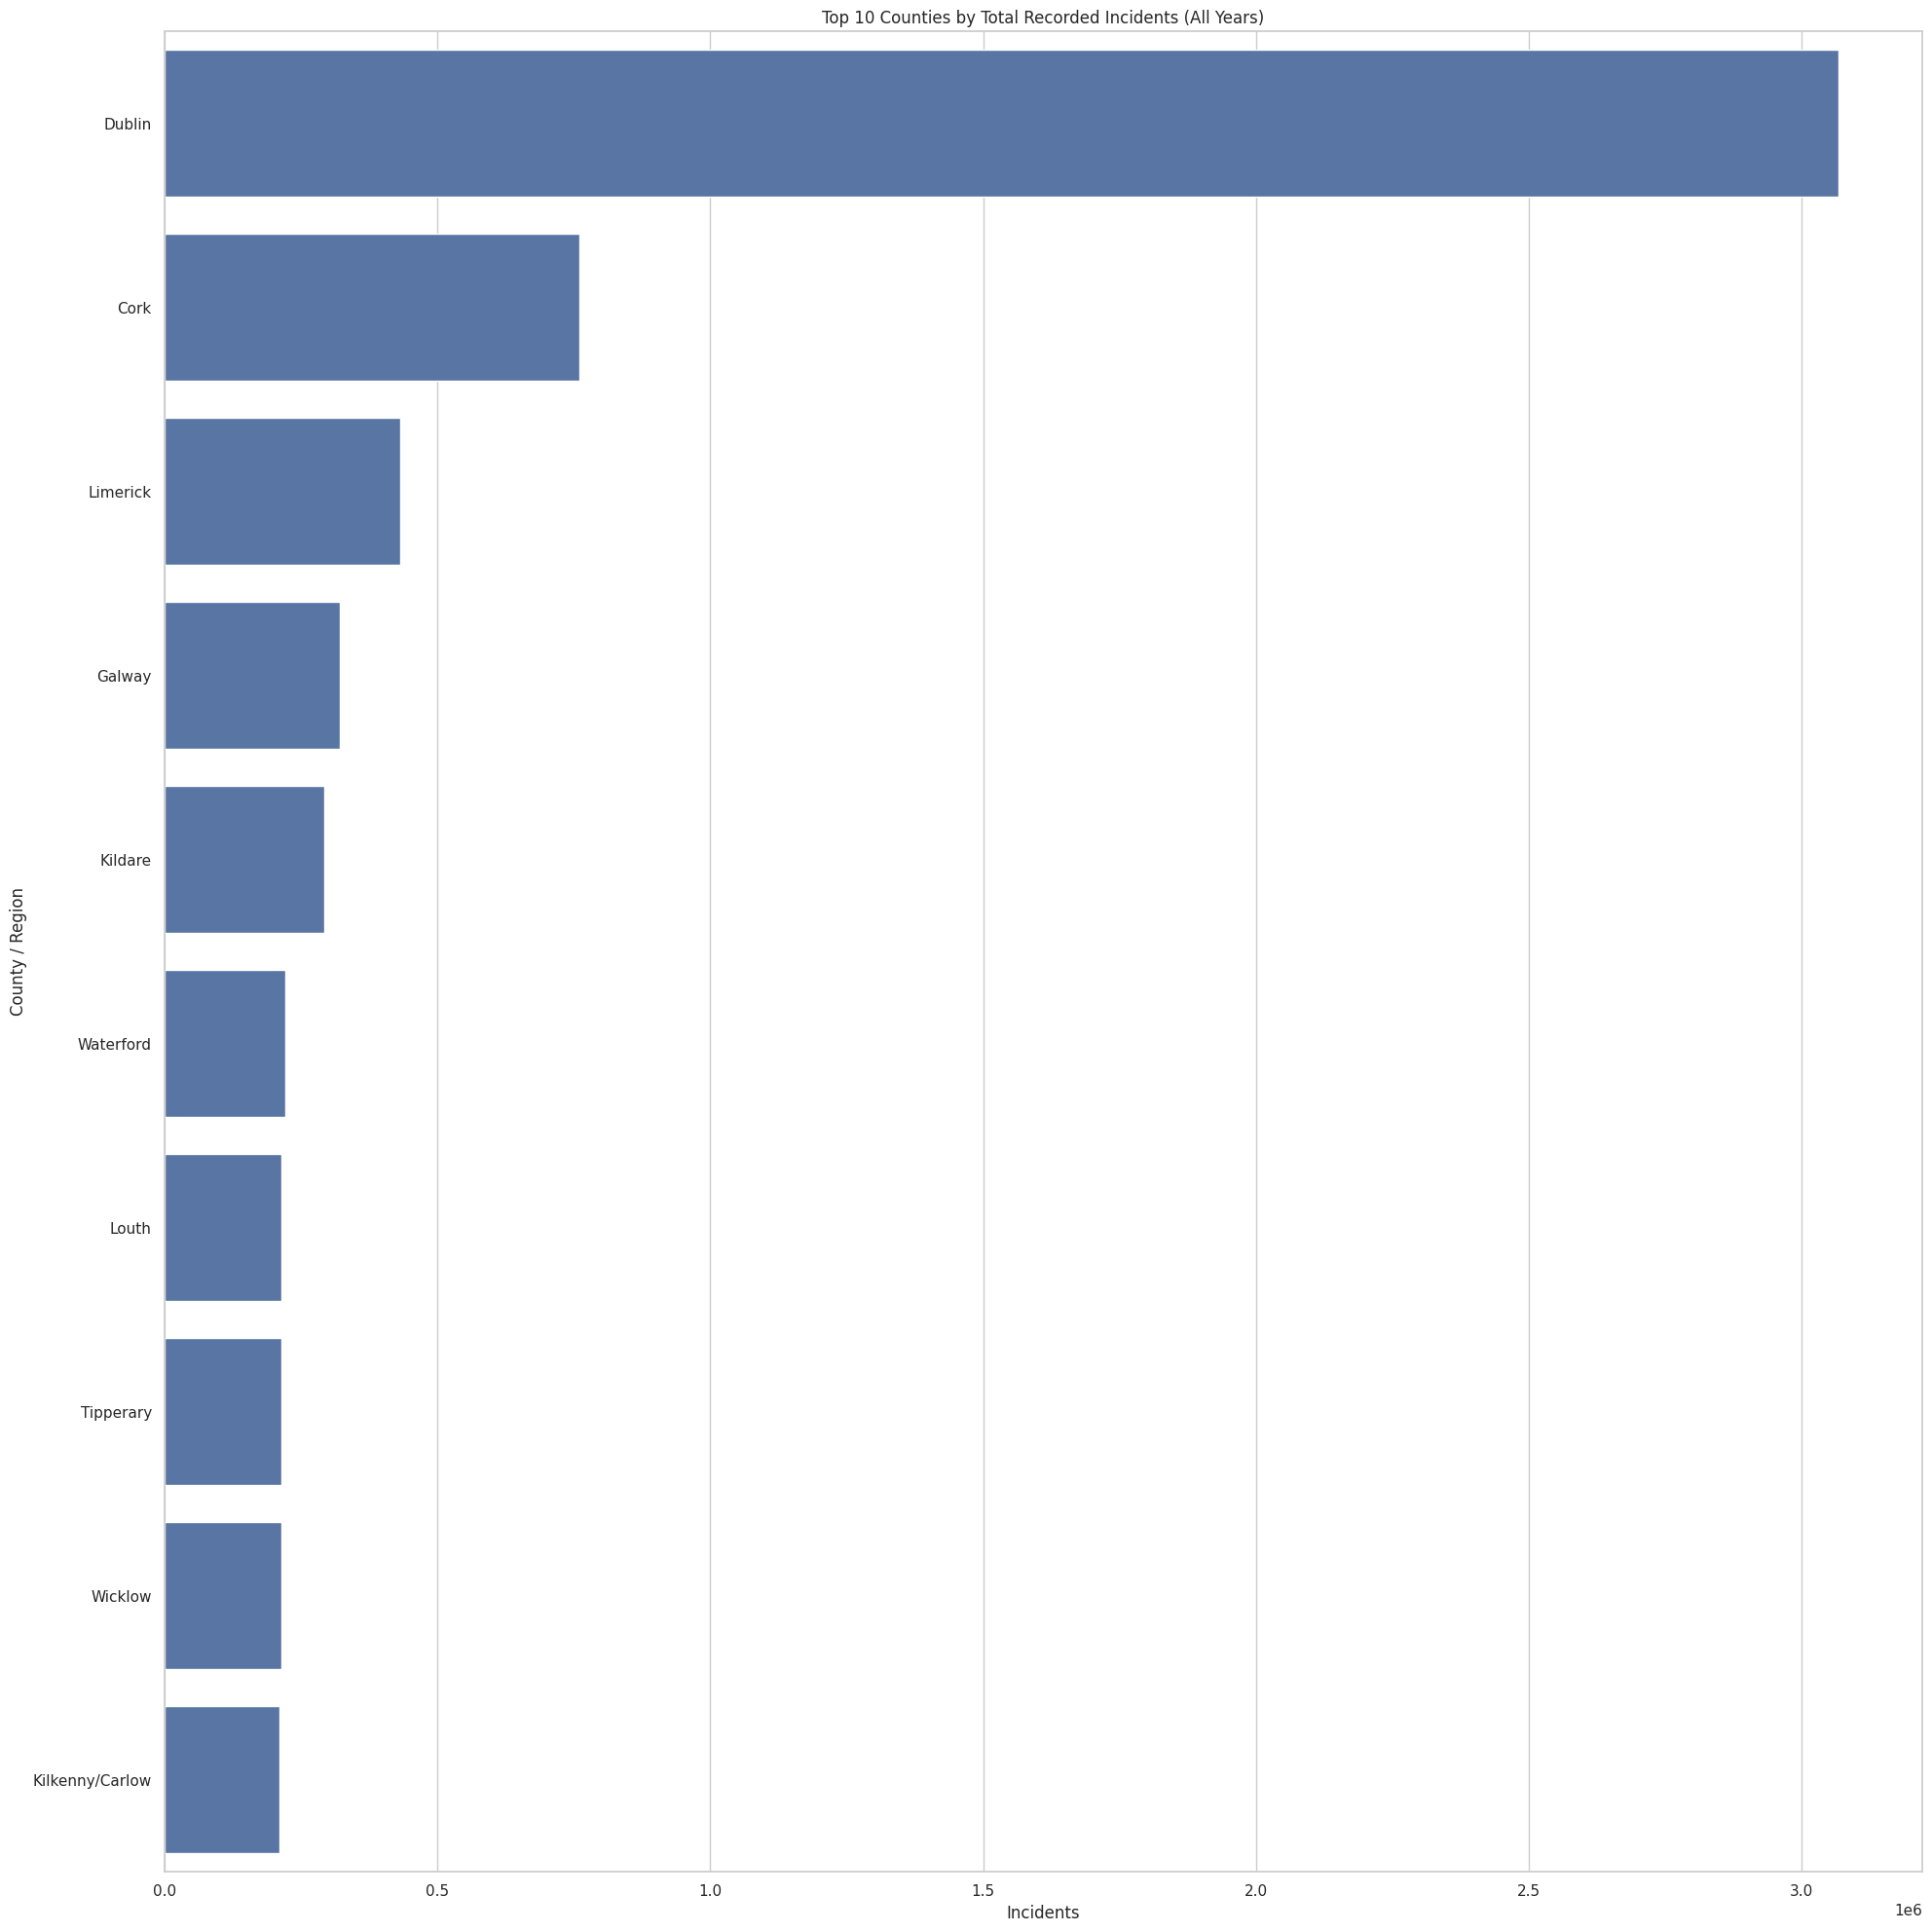

In [41]:
# County-level concentration analysis
# Total incidents by county/region (all years)
county_totals = (
    df.groupby("county", as_index=False)["incidents"]
      .sum()
      .sort_values("incidents", ascending=False)
      .reset_index(drop=True)
)

print("Top 10 counties by total recorded incidents:")
display(county_totals.head(10))

# Plot top counties/regions for readability
top_n = 10
plt.figure(figsize=(20, 20))
sns.barplot(
    data=county_totals.head(top_n),
    x="incidents",
    y="county",
    order=county_totals.head(top_n)["county"]
)
plt.title(f"Top {top_n} Counties by Total Recorded Incidents (All Years)")
plt.xlabel("Incidents")
plt.ylabel("County / Region")
plt.tight_layout()
plt.show()



In [42]:
# Share and cumulative concentration
total_national = county_totals["incidents"].sum()

county_totals["share_pct"] = county_totals["incidents"] / total_national * 100

county_totals["cumulative_share_pct"] = county_totals["share_pct"].cumsum()

display(county_totals.head(10))


,county,incidents,share_pct,cumulative_share_pct
0,Dublin,3067279,39.427820,39.427820
1,Cork,759886,9.767826,49.195647
2,Limerick,432494,5.559421,54.755068
3,Galway,321921,4.138079,58.893147
4,Kildare,291815,3.751087,62.644234
5,Waterford,221666,2.849368,65.493602
6,Louth,214431,2.756367,68.249969
7,Tipperary,214147,2.752716,71.002685
8,Wicklow,213663,2.746495,73.749180
9,Kilkenny/Carlow,210329,2.703639,76.452819


3 counties together account for at least 50% of total recorded incidents. 



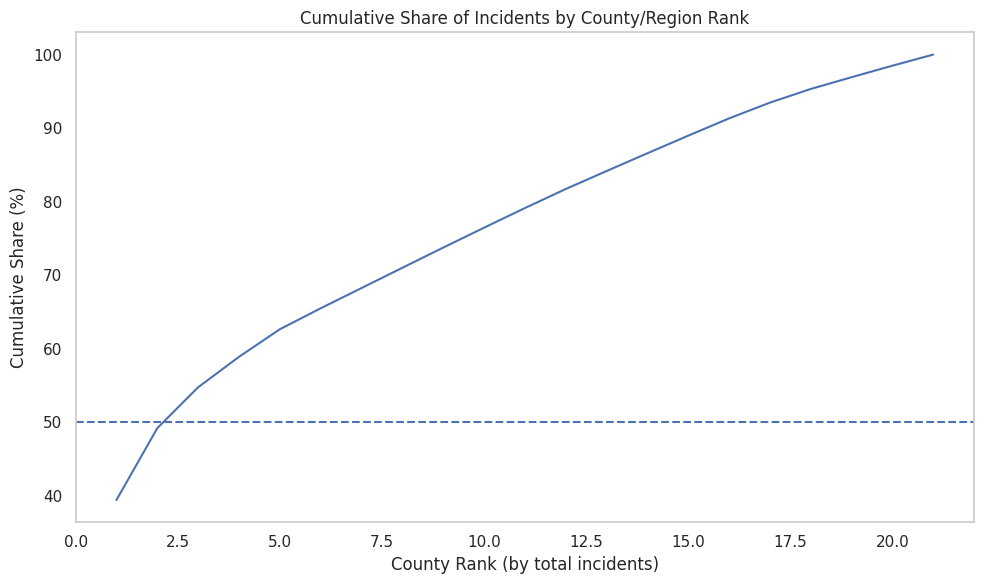

In [43]:
# How many counties/regions account for at least 50% of incidents?
first_crossing_position = (county_totals["cumulative_share_pct"] >= 50).idxmax()
num_counties_50 = first_crossing_position + 1

print(f"{num_counties_50} counties together account for at least 50% of total recorded incidents. \n")

# concentration curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(county_totals) + 1), county_totals["cumulative_share_pct"])
plt.axhline(50, linestyle="--")
plt.title("Cumulative Share of Incidents by County/Region Rank")
plt.xlabel("County Rank (by total incidents)")
plt.ylabel("Cumulative Share (%)")
plt.grid(False)
plt.tight_layout()
plt.show()

Aggregating incidents by county confirms a strong geographic concentration of recorded crime. Dublin accounts for approximately 39.4% of all recorded incidents nationally, making it the dominant contributor by a substantial margin. Cork follows at 9.8%, with Limerick (5.6%) and Galway (4.1%) forming the next highest contributors.

The cumulative-share analysis shows that just the top two counties (Dublin and Cork) account for nearly 50% of total recorded incidents nationally. Expanding to the top five counties (Dublin, Cork, Limerick, Galway, and Kildare) captures over 62% of total incidents.

This pattern reinforces the strong urban and metropolitan concentration observed at both division and station levels. Crime burden is not evenly distributed geographically, with Dublin in particular representing a structurally dominant share of national recorded incidents. This geographic concentration provides further justification for targeted, data-driven prioritisation at division and station level in the subsequent risk framework.

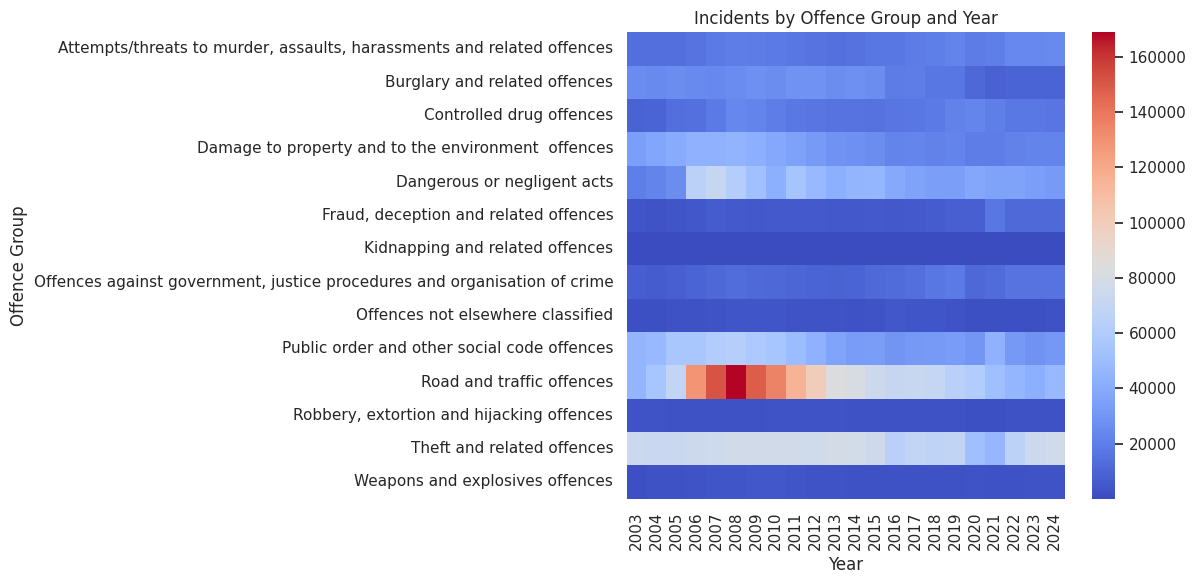

In [44]:
# Temporal distribution heatmaps

# Year x Offence Group heatmap
offence_year_matrix = df.pivot_table(
    index="offence_group_name",
    columns="year",
    values="incidents",
    aggfunc="sum",
    fill_value=0,
)

plt.figure(figsize=(12, 6))
sns.heatmap(offence_year_matrix, cmap="coolwarm")
plt.title("Incidents by Offence Group and Year")
plt.xlabel("Year")
plt.ylabel("Offence Group")
plt.tight_layout()
plt.show()

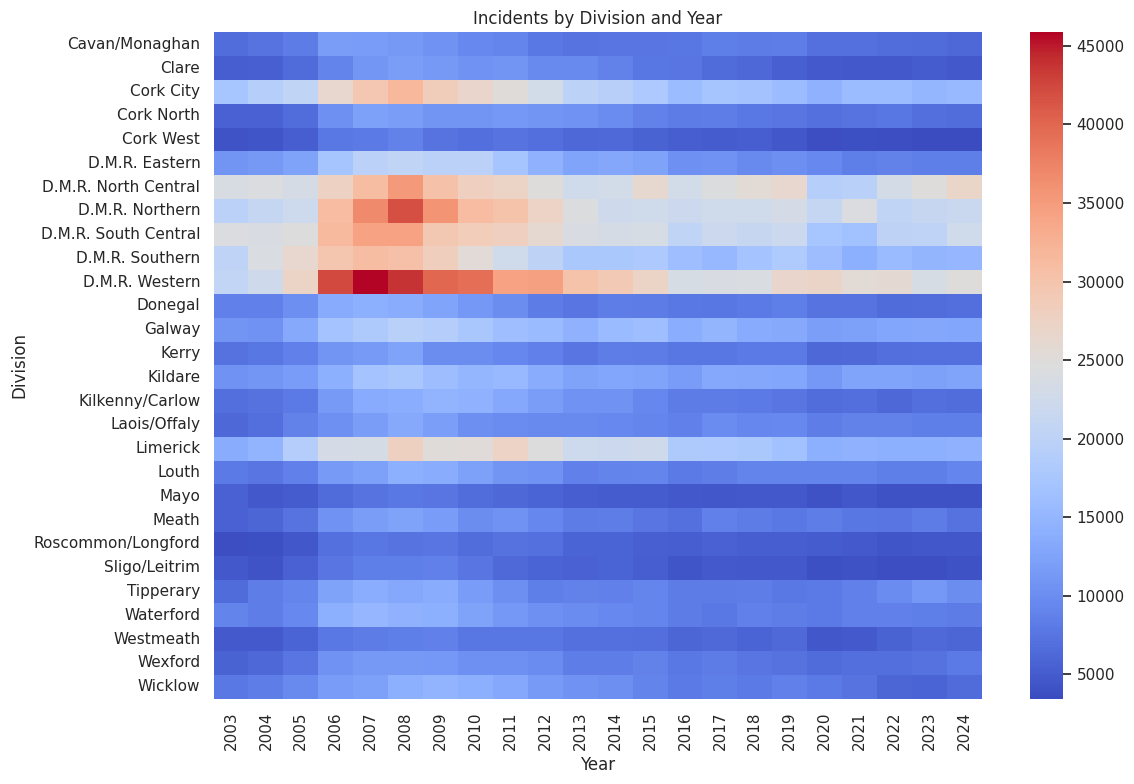

In [45]:
# Year x Division heatmap
division_year_matrix = df.pivot_table(
    index="station_division",
    columns="year",
    values="incidents",
    aggfunc="sum",
    fill_value=0,
)

plt.figure(figsize=(12, 8))
sns.heatmap(division_year_matrix, cmap="coolwarm")
plt.title("Incidents by Division and Year")
plt.xlabel("Year")
plt.ylabel("Division")
plt.tight_layout()
plt.show()

Heatmaps of incidents by year reveal that the late-2000s peak is visible across most offence categories and divisions, confirming that the national spike was broad-based rather than isolated. Road and traffic offences display the most pronounced peak, while theft-related offences remain structurally persistent over time.

At division level, Dublin Metropolitan Region divisions consistently show higher incident intensity relative to other areas. The 2020 dip is observable across most divisions and offence groups, suggesting a systemic temporal disruption rather than a localised change.

Overall, the temporal patterns appear nationally coordinated rather than geographically isolated, supporting the use of consistent historical (2015–2019) and recent (2020–2024) comparison windows in the subsequent station-level risk framework.

In [46]:
# Station Risk Framework (Offence-level base table)

# Define periods for risk metrics
recent_start, recent_end = 2020, 2024
hist_start, hist_end     = 2015, 2019

recent_mask = df["year"].between(recent_start, recent_end)
hist_mask   = df["year"].between(hist_start, hist_end)

# Aggregate incidents by station & offence group for each period
group_cols = ["station_code", "station_name", "station_division", "county", "offence_group_name"]

recent_agg = (
    df[recent_mask]
    .groupby(group_cols, as_index=False)["incidents"]
    .sum()
    .rename(columns={"incidents": "incidents_recent"})
)

hist_agg = (
    df[hist_mask]
    .groupby(group_cols, as_index=False)["incidents"]
    .sum()
    .rename(columns={"incidents": "incidents_hist"})
)

# Merge historical + recent (outer keeps offence groups that appear in only one period)
risk_df = (
    pd.merge(
        hist_agg,
        recent_agg,
        on=group_cols,
        how="outer",
    )
    .fillna(0)
)

print(f"Dataframe after merging historical & recent incidents are : {risk_df.shape}\n")
display(risk_df)



Dataframe after merging historical & recent incidents are : (7896, 7)



,station_code,station_name,station_division,county,offence_group_name,incidents_hist,incidents_recent
0,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,"Attempts/threats to murder, assaults, harassme...",143,180
1,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,Burglary and related offences,88,30
2,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,Controlled drug offences,97,84
3,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,Damage to property and to the environment off...,157,139
4,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,Dangerous or negligent acts,177,100
...,...,...,...,...,...,...,...
7891,512015,Carrig na Bhfear,Cork City,Cork,Public order and other social code offences,10,20
7892,512015,Carrig na Bhfear,Cork City,Cork,Road and traffic offences,20,17
7893,512015,Carrig na Bhfear,Cork City,Cork,"Robbery, extortion and hijacking offences",0,0
7894,512015,Carrig na Bhfear,Cork City,Cork,Theft and related offences,49,83


In [47]:
# Total incidents across all years (station context)
total_incidents = (
    df.groupby(["station_code", "station_name", "station_division", "county"], as_index=False)["incidents"]
      .sum()
      .rename(columns={"incidents": "incidents_total_all_years"})
)

risk_df = risk_df.merge(
    total_incidents,
    on=["station_code", "station_name", "station_division", "county"],
    how="left"
)

# Growth metrics
risk_df["growth_abs"] = risk_df["incidents_recent"] - risk_df["incidents_hist"]

# Growth rate (safe): NaN when hist==0 to avoid infinite ratios
risk_df["growth_rate"] = np.where(
    risk_df["incidents_hist"] > 0,
    risk_df["growth_abs"] / risk_df["incidents_hist"],
    np.nan
)

# Flag "new activity" offence groups (present recently but not historically)
risk_df["new_activity_flag"] = (risk_df["incidents_hist"] == 0) & (risk_df["incidents_recent"] > 0)

# Optional capped ratio for interpretability (prevents extreme values dominating)
risk_df["growth_ratio_capped"] = np.where(
    risk_df["incidents_hist"] > 0,
    risk_df["incidents_recent"] / risk_df["incidents_hist"],
    np.nan
)
risk_df["growth_ratio_capped"] = risk_df["growth_ratio_capped"].clip(upper=10)  # cap at 10x (tunable)


print("Hist years rows:", hist_agg.shape[0], "Recent years rows:", recent_agg.shape[0])
print("Any missing county after merge?:", risk_df["county"].isna().sum())

# Quick preview
display(
    risk_df.sort_values(["station_name", "offence_group_name"]).head(20)
)

Hist years rows: 7896 Recent years rows: 7896
Any missing county after merge?: 0


,station_code,station_name,station_division,county,offence_group_name,incidents_hist,incidents_recent,incidents_total_all_years,growth_abs,growth_rate,new_activity_flag,growth_ratio_capped
4438,35301,Abbeyfeale,Limerick,Limerick,"Attempts/threats to murder, assaults, harassme...",85,152,10121,67,0.788235,False,1.788235
4439,35301,Abbeyfeale,Limerick,Limerick,Burglary and related offences,102,51,10121,-51,-0.500000,False,0.500000
4440,35301,Abbeyfeale,Limerick,Limerick,Controlled drug offences,51,42,10121,-9,-0.176471,False,0.823529
4441,35301,Abbeyfeale,Limerick,Limerick,Damage to property and to the environment off...,104,63,10121,-41,-0.394231,False,0.605769
4442,35301,Abbeyfeale,Limerick,Limerick,Dangerous or negligent acts,1428,340,10121,-1088,-0.761905,False,0.238095
4443,35301,Abbeyfeale,Limerick,Limerick,"Fraud, deception and related offences",18,50,10121,32,1.777778,False,2.777778
4444,35301,Abbeyfeale,Limerick,Limerick,Kidnapping and related offences,1,1,10121,0,0.000000,False,1.000000
4445,35301,Abbeyfeale,Limerick,Limerick,"Offences against government, justice procedure...",33,6,10121,-27,-0.818182,False,0.181818
4446,35301,Abbeyfeale,Limerick,Limerick,Offences not elsewhere classified,19,10,10121,-9,-0.473684,False,0.526316
4447,35301,Abbeyfeale,Limerick,Limerick,Public order and other social code offences,146,82,10121,-64,-0.438356,False,0.561644


In [48]:
# sanity check
print("risk_df shape:", risk_df.shape)
print("New-activity rows:", int(risk_df["new_activity_flag"].sum()))

risk_df shape: (7896, 12)
New-activity rows: 367


In [49]:
# EXPORT: 564 Stations × 14 Offences (7,896 rows)

print(f"✅ station_offence_metrics.csv: {risk_df.shape[0]} rows ✓")
display(risk_df.head())



✅ station_offence_metrics.csv: 7896 rows ✓


,station_code,station_name,station_division,county,offence_group_name,incidents_hist,incidents_recent,incidents_total_all_years,growth_abs,growth_rate,new_activity_flag,growth_ratio_capped
0,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,"Attempts/threats to murder, assaults, harassme...",143,180,7452,37,0.258741,False,1.258741
1,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,Burglary and related offences,88,30,7452,-58,-0.659091,False,0.340909
2,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,Controlled drug offences,97,84,7452,-13,-0.134021,False,0.865979
3,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,Damage to property and to the environment off...,157,139,7452,-18,-0.114650,False,0.885350
4,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,Dangerous or negligent acts,177,100,7452,-77,-0.435028,False,0.564972


To move from descriptive EDA into prioritisation, incidents were aggregated at station × offence-group level for two windows: a historical baseline (2015–2019) and a recent period (2020–2024). The resulting table (risk_df) enables consistent like-for-like comparison across stations and offence categories. Data integrity checks confirm both periods contain the same number of station–offence rows (7,896 each) and that the county mapping is complete (0 missing counties after merge). A total of 367 station–offence combinations are flagged as new activity (present in the recent period but absent historically), which is useful for detecting emerging issues.

In [50]:
# Roll up offence-level risk_df to station-level risk metrics

eps = 1e-6  # small constant for safety (not used for scoring ratios directly)

station_risk = (
    risk_df
    .groupby(["station_code", "station_name", "station_division", "county"], as_index=False)
    .agg(
        incidents_recent=("incidents_recent", "sum"),
        incidents_hist=("incidents_hist", "sum"),
        incidents_total_all_years=("incidents_total_all_years", "max"),
        new_activity_flag=("new_activity_flag", "max"),  # if any offence group is new at this station
    )
)

# Growth metrics
station_risk["growth_abs"] = station_risk["incidents_recent"] - station_risk["incidents_hist"]

# Safe proportional growth (avoid infinite values when hist==0)
station_risk["growth_rate"] = np.where(
    station_risk["incidents_hist"] > 0,
    station_risk["growth_abs"] / station_risk["incidents_hist"],
    np.nan
)

# Optional: capped ratio for interpretability + stable scoring
station_risk["growth_ratio_capped"] = pd.Series(
    np.where(
        station_risk["incidents_hist"] > 0,
        station_risk["incidents_recent"] / station_risk["incidents_hist"],
        np.nan
    ),
    index=station_risk.index # Ensure the index is preserved
).clip(upper=10)

# Fill NaNs for scoring (hist==0 cases). Keep the raw NaN growth_rate for reporting if you want.
station_risk["growth_rate_filled"] = station_risk["growth_rate"].fillna(0)

# Normalise components (min–max scaling)

def minmax(s):
    smin, smax = s.min(), s.max()
    if smax == smin:
        return s * 0  # all zeros if constant
    return (s - smin) / (smax - smin)

station_risk["recent_norm"] = minmax(station_risk["incidents_recent"])
station_risk["growth_norm"] = minmax(station_risk["growth_rate_filled"])

# Composite Risk Index (tunable weights)
station_risk["risk_index"] = 0.6 * station_risk["recent_norm"] + 0.4 * station_risk["growth_norm"]

# Rank stations
station_risk = station_risk.sort_values("risk_index", ascending=False).reset_index(drop=True)
station_risk["rank_risk"] = station_risk.index + 1

# Preview top 20
top20_risk = station_risk.head(20).copy()
display(top20_risk[[
    "rank_risk", "station_name", "station_division", "county",
    "incidents_recent", "incidents_hist",
    "growth_abs", "growth_rate", "risk_index"
]])




,rank_risk,station_name,station_division,county,incidents_recent,incidents_hist,growth_abs,growth_rate,risk_index
0,1,Store Street,D.M.R. North Central,Dublin,53759,60110,-6351,-0.105656,0.684059
1,2,Pearse Street,D.M.R. South Central,Dublin,47382,59550,-12168,-0.204332,0.599498
2,3,Blanchardstown,D.M.R. Western,Dublin,36947,38172,-1225,-0.032092,0.506330
3,4,Bridewell Dublin,D.M.R. North Central,Dublin,35523,39405,-3882,-0.098515,0.481435
4,5,Tallaght,D.M.R. Southern,Dublin,33944,37012,-3068,-0.082892,0.465923
5,6,Ballyporeen,Tipperary,Tipperary,313,97,216,2.226804,0.403316
6,7,Waterford,Waterford,Waterford,24331,24085,246,0.010214,0.371212
7,8,Gaillimh,Galway,Galway,26106,31196,-5090,-0.163162,0.367544
8,9,An Spideal,Galway,Galway,762,267,495,1.853933,0.357822
9,10,Nenagh,Tipperary,Tipperary,11071,5536,5535,0.999819,0.357221


The offence-level risk table was then rolled up to station level by summing incidents across all offence groups for each station. Two components were used for the composite risk index:

Recent workload level (total incidents in 2020–2024)

Growth signal (proportional change relative to 2015–2019)

These components were normalised and combined into a single risk_index to produce an operational ranking. The top of the ranking is dominated by high-volume Dublin stations, with Store Street (#1) and Pearse Street (#2) leading the list, followed by other large urban stations such as Blanchardstown, Bridewell Dublin, and Tallaght. At the same time, several non-Dublin stations also appear in the top 20 (e.g., Waterford, Nenagh, Drogheda, Naas, Glynn), indicating that the index is not only capturing Dublin volume, but also highlighting stations with notable growth dynamics.

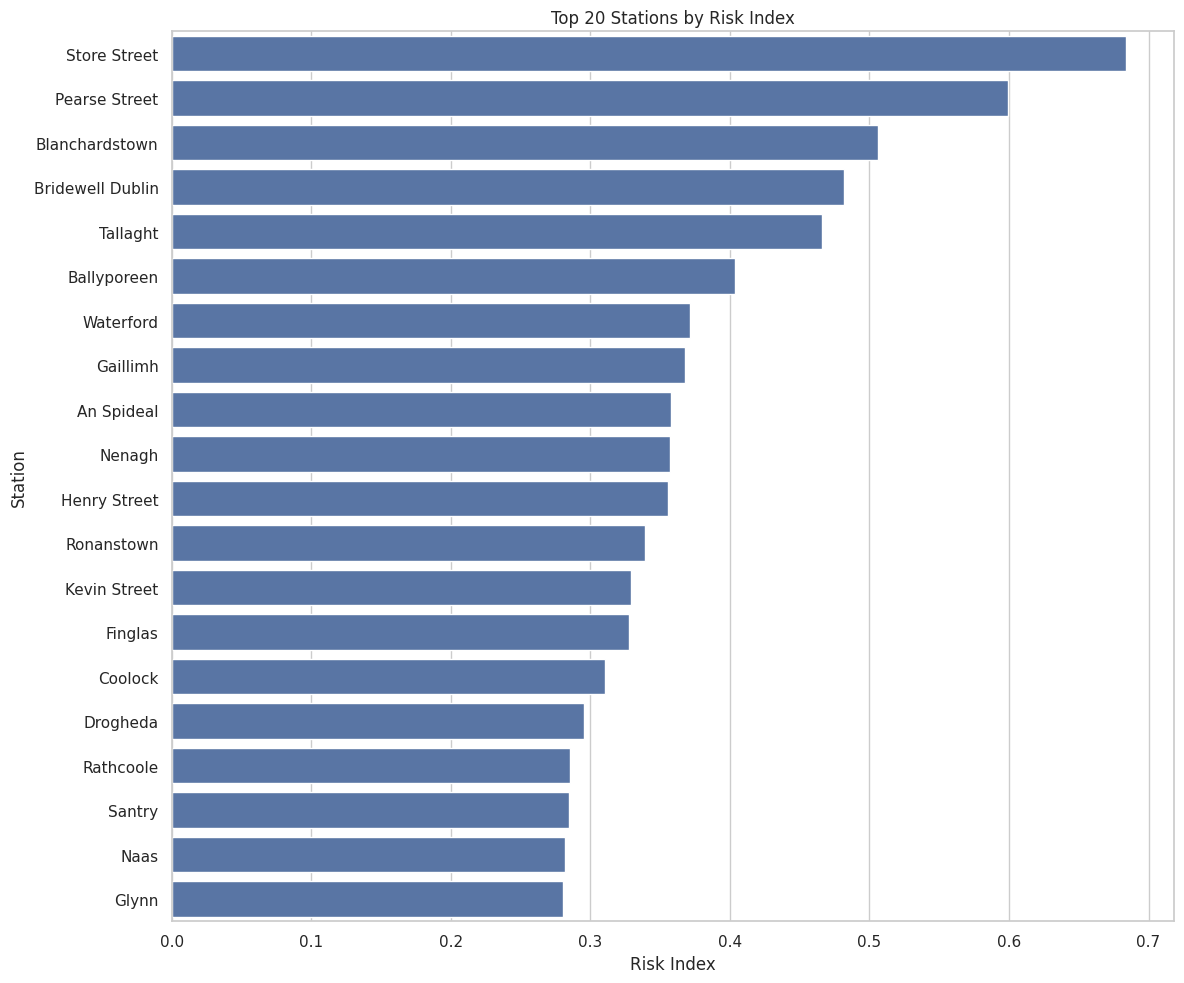

In [51]:
# Plot top 20
plt.figure(figsize=(12, 10))
sns.barplot(
    data=top20_risk,
    x="risk_index",
    y="station_name",
    order=top20_risk["station_name"]
)
plt.title("Top 20 Stations by Risk Index")
plt.xlabel("Risk Index")
plt.ylabel("Station")
plt.tight_layout()
plt.show()


## Decision lens

This Risk Index ranking can be used to:  
- **Flag structurally high-demand stations** (Dublin top 5) that are candidates for sustained resource support.  
- **Identify smaller stations with unusually fast growth** (Nenagh, An Spideal, Ballyporeen) that may need targeted interventions.  
- **Shortlist stations for deeper review** by division leadership, combining this with local knowledge of staffing and population.


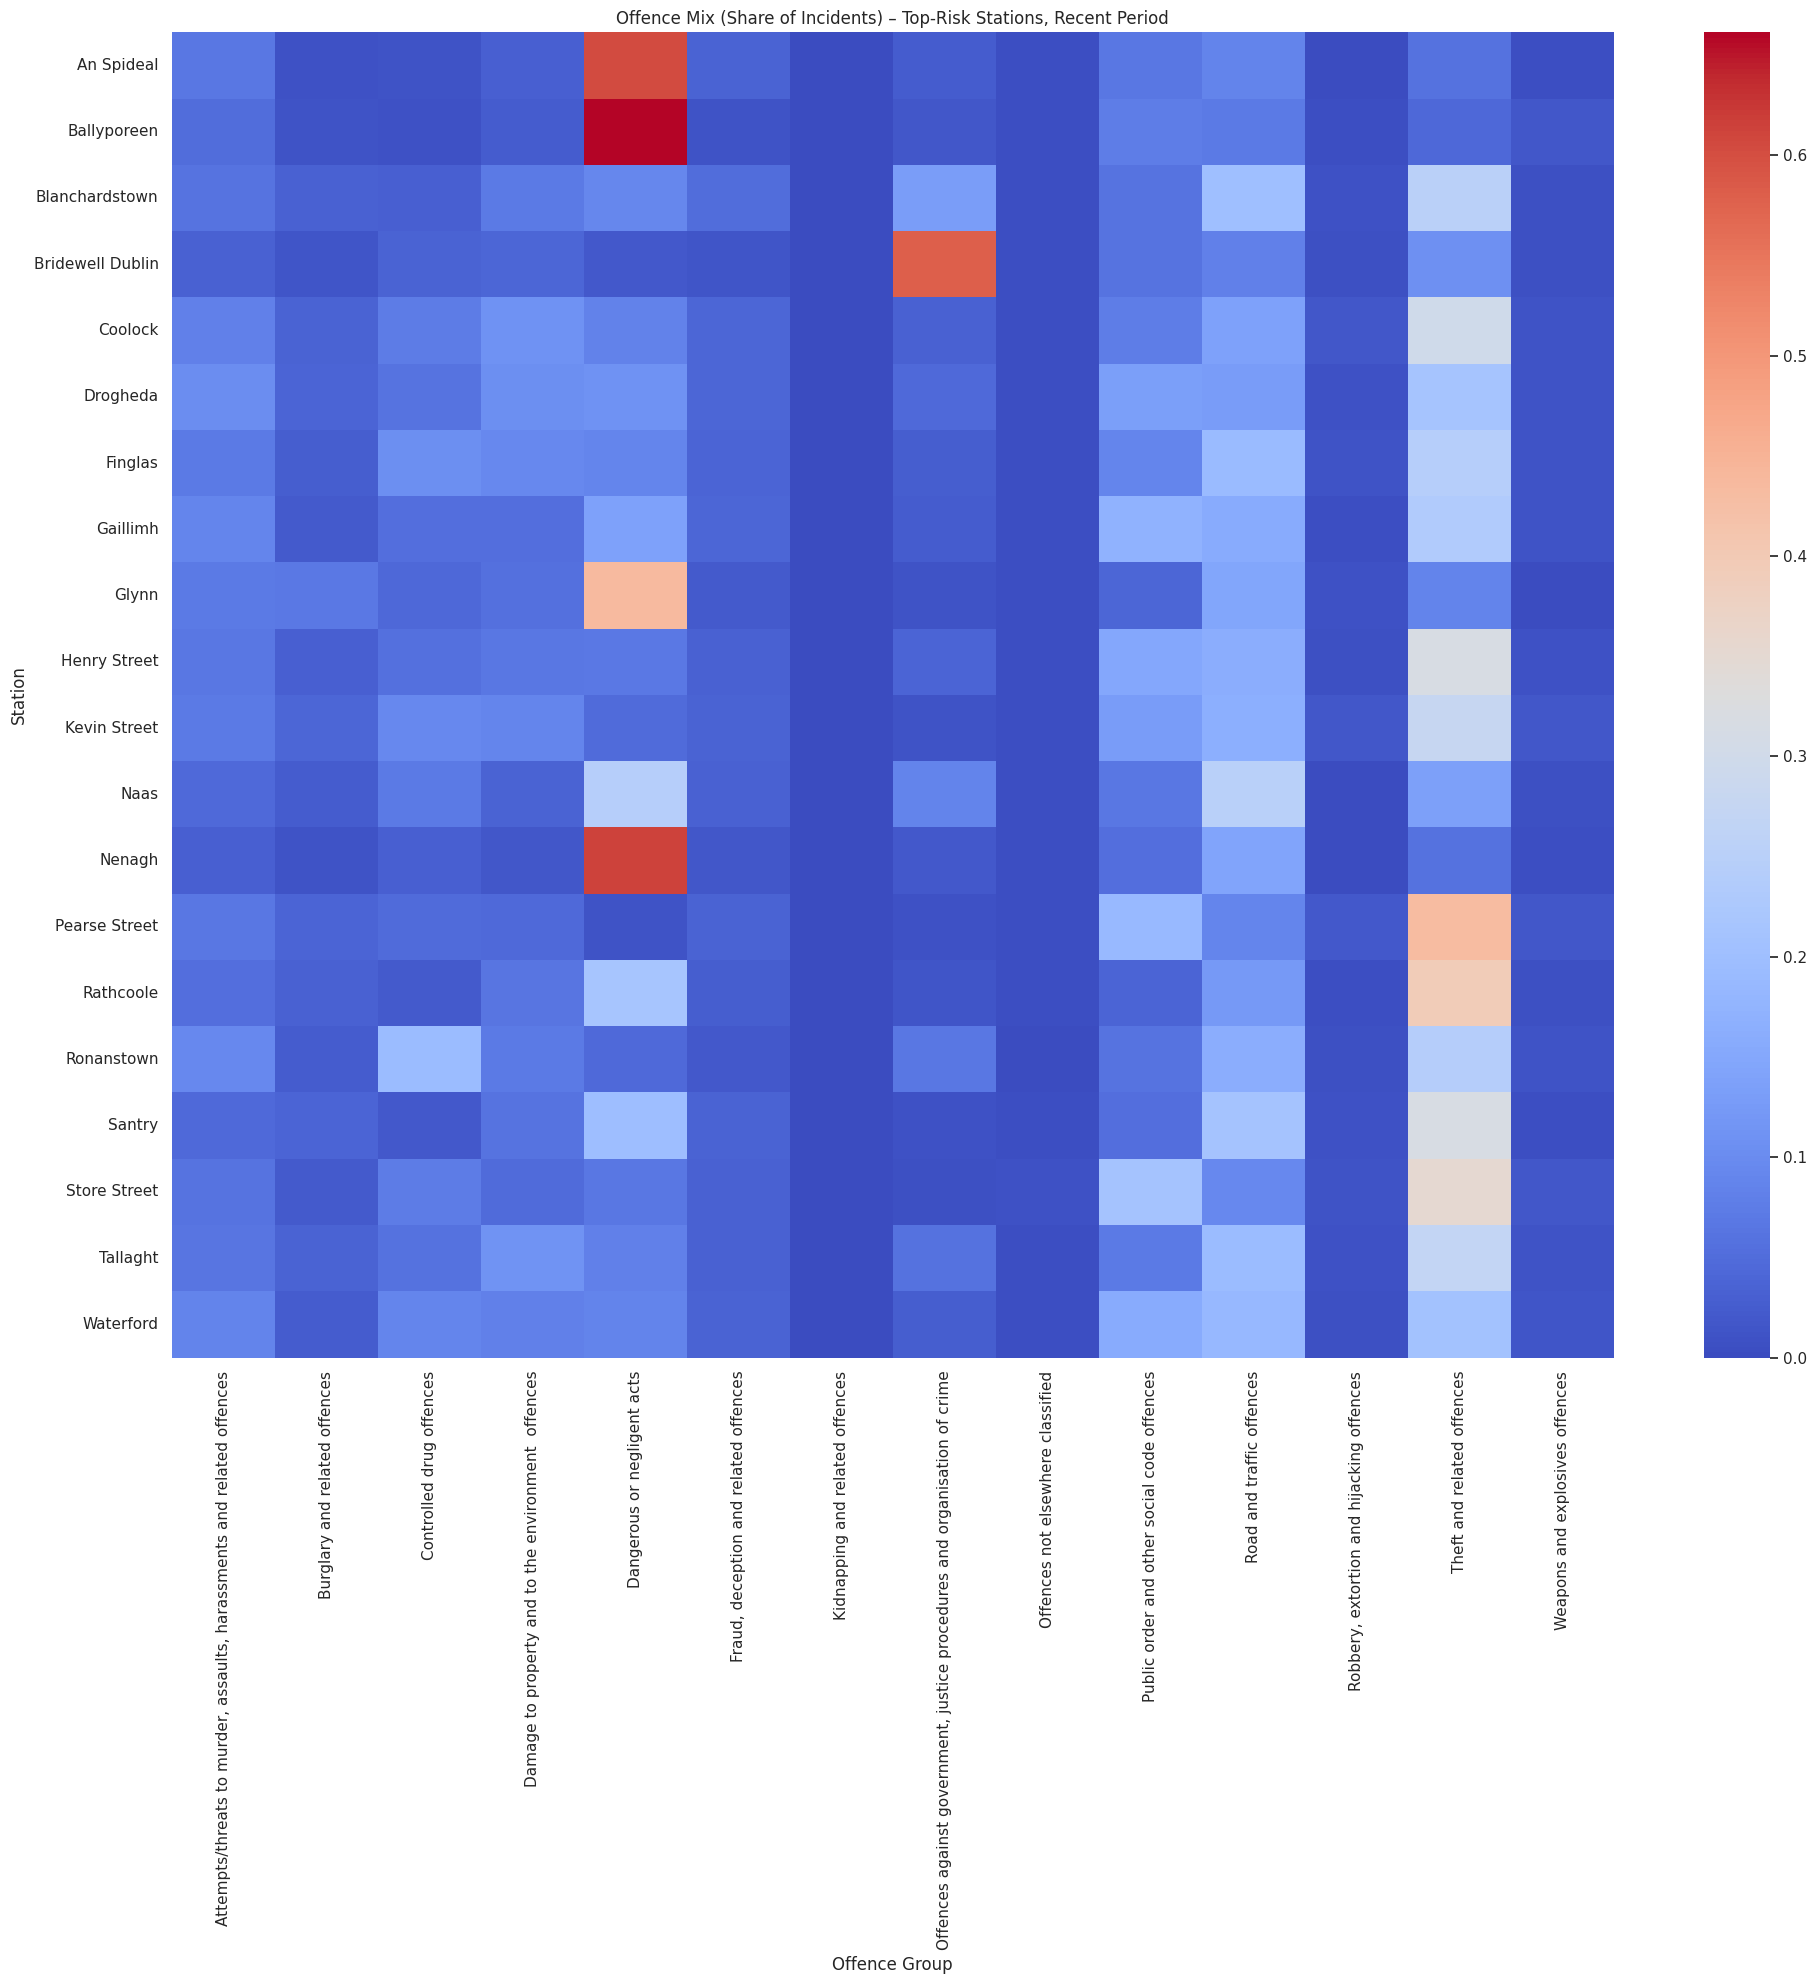

In [52]:
# Offence mix (share) for top-risk stations — recent period

top_codes = top20_risk["station_code"].tolist()

recent_mix = (
    df[recent_mask & df["station_code"].isin(top_codes)]
    .groupby(["station_name", "offence_group_name"], as_index=False)["incidents"]
    .sum()
)

heat_df = recent_mix.pivot_table(
    index="station_name",
    columns="offence_group_name",
    values="incidents",
    aggfunc="sum",
    fill_value=0,
)

# Convert to share of each station's recent incidents
heat_df = heat_df.div(heat_df.sum(axis=1), axis=0)

plt.figure(figsize=(20,20))
sns.heatmap(heat_df, cmap="coolwarm")
plt.title("Offence Mix (Share of Incidents) – Top-Risk Stations, Recent Period")
plt.xlabel("Offence Group")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

### Operational implications (illustrative)

The analysis supports these prioritisation actions:  

| Priority | Stations | Rationale | Next step |
|----------|----------|-----------|-----------|
| High | Store Street, Pearse Street, Blanchardstown | Structural workload >50k incidents/year | Review current staffing vs national benchmarks |
| Medium | Waterford, Nenagh, Drogheda, Naas | High risk index despite lower absolute volume | Local review: growth drivers? |
| Watch | Ballyporeen, An Spideal, Glynn | Extreme relative growth (2x+) from small base | Monitor + validate data quality |

*Note: These are data‑driven inputs only. Actual decisions require local context on staffing, population, and priorities.*


For interpretability, the offence composition of the top-risk stations was profiled using a heatmap of offence shares (each row sums to 100%). Across the top-risk group, Theft and related offences and Road and traffic offences appear as consistently strong contributors. Several stations show clearer concentration patterns (brighter cells) where one or two offence groups dominate their recent workload—useful for tailoring interventions (e.g., targeted theft operations vs public order enforcement vs traffic policing), rather than applying uniform resourcing.

Urban station (high-volume): Pearse Street
Lower-volume station: Templederry


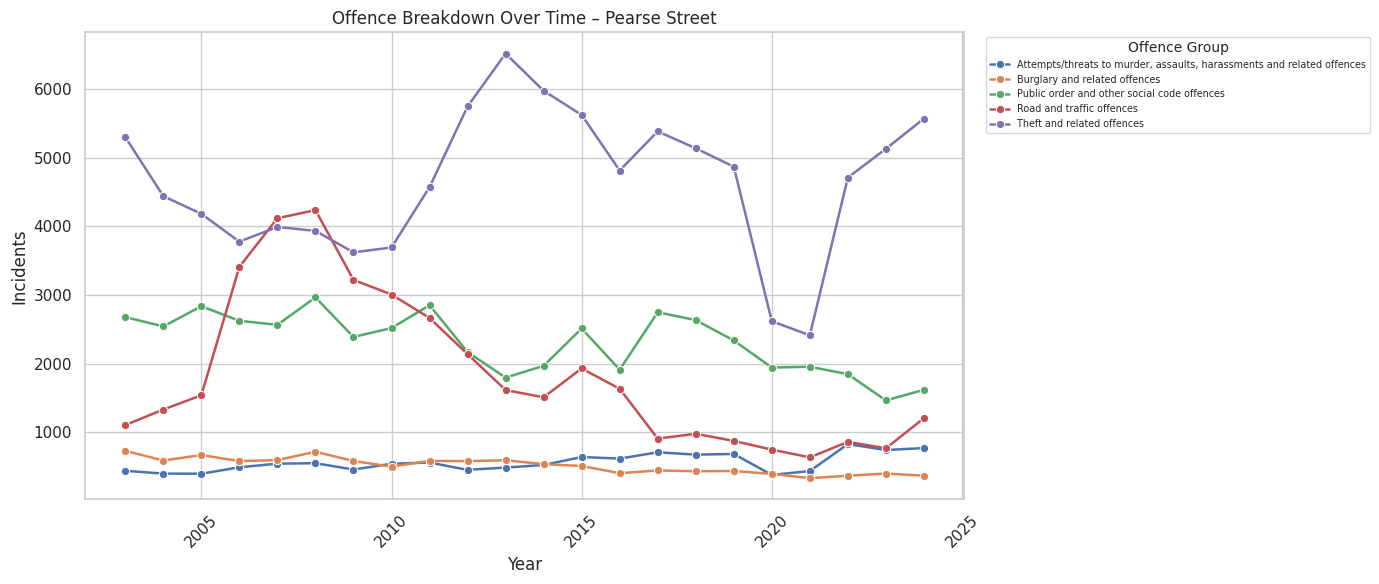

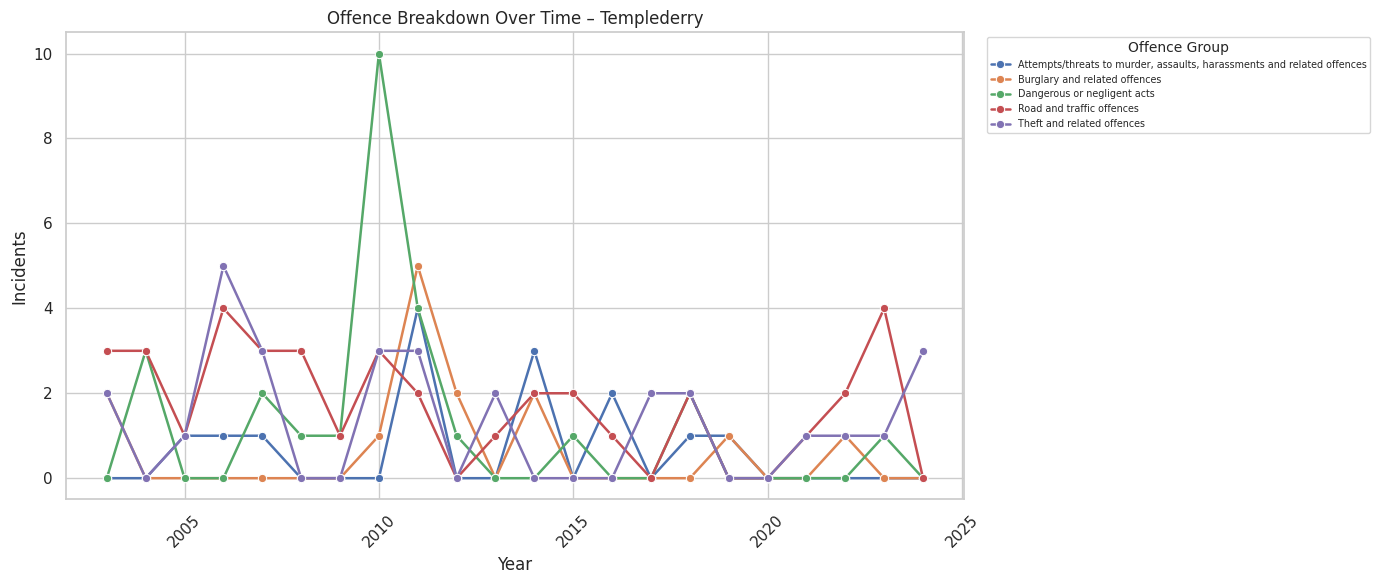

In [53]:
# -----------------------------------------
# Case Study: Offence Breakdown Over Time (Urban vs Lower-Volume Station)
# -----------------------------------------

# Build a stable station total table (if not already available)
station_totals = (
    df.groupby(["station_code", "station_name", "station_division", "county"], as_index=False)["incidents"]
      .sum()
      .sort_values("incidents", ascending=False)
      .reset_index(drop=True)
)

# 1) Pick an urban/high-volume station (top 1 by total incidents)
urban_station = station_totals.loc[0, "station_name"]

# 2) Pick a lower-volume station (bottom quartile), preferably non-Dublin
bottom_quartile = station_totals["incidents"].quantile(0.25)

candidate_rural = station_totals[
    (station_totals["incidents"] <= bottom_quartile) &
    (station_totals["county"] != "Dublin") &
    (station_totals["incidents"] >= 3000)   # avoids extremely tiny stations (tune if needed)
].sort_values("incidents", ascending=True)

# Fallback if filtering is too strict
if candidate_rural.empty:
    candidate_rural = station_totals.tail(50).sort_values("incidents", ascending=True)

rural_station = candidate_rural.iloc[0]["station_name"]

print("Urban station (high-volume):", urban_station)
print("Lower-volume station:", rural_station)

example_stations = [urban_station, rural_station]

# Aggregate yearly incidents by offence group for the selected stations
station_offence_year = (
    df[df["station_name"].isin(example_stations)]
      .groupby(["station_name", "year", "offence_group_name"], as_index=False)["incidents"]
      .sum()
)

# Top 5 Offence Groups per Station

def plot_top5_station_trends(station_name):

    station_data = station_offence_year[
        station_offence_year["station_name"] == station_name
    ]

    # Identify top 5 offence groups by total incidents (recent period)
    top5 = (
        station_data.groupby("offence_group_name")["incidents"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist()
    )

    filtered = station_data[
        station_data["offence_group_name"].isin(top5)
    ]

def plot_station_offence_trends(station_name):
    station_data = station_offence_year[station_offence_year["station_name"] == station_name]

    # Identify top 5 offence groups by total incidents for the current station
    top5_offences = (
        station_data.groupby("offence_group_name")["incidents"]
        .sum()
        .nlargest(5) # Get top 5
        .index.tolist()
    )

    # Filter data to include only top 5 offences
    filtered_data = station_data[station_data["offence_group_name"].isin(top5_offences)]

    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=filtered_data,
        x="year",
        y="incidents",
        hue="offence_group_name",
        marker="o",
        linewidth=1.8
    )
    plt.title(f"Offence Breakdown Over Time – {station_name}")
    plt.xlabel("Year")
    plt.ylabel("Incidents")
    plt.xticks(rotation=45)

    # Make legend readable
    plt.legend(
        title="Offence Group",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize="xx-small",
        title_fontsize="small"
    )

    plt.tight_layout()
    plt.show()

plot_station_offence_trends(urban_station)
plot_station_offence_trends(rural_station)

To add interpretability to the station risk ranking, we compare a high-volume urban station (Pearse Street) with a lower-volume station (Templederry). Only the five highest-volume offence groups are shown to focus on dominant workload drivers.

Pearse Street (Urban, High Volume)

Pearse Street shows sustained high incident volumes across multiple categories. Theft and related offences clearly dominate, followed by public order and road/traffic offences. A strong peak is visible in the late 2000s, followed by a structural decline and partial recovery after 2020.

The station’s high risk ranking is therefore driven by consistent scale rather than short-term spikes.

Templederry (Lower Volume)

Templederry records very low absolute incident counts across all offence groups. Patterns appear volatile due to small base effects, but overall workload remains minimal compared to urban stations.

Interpretation

This comparison highlights the structural difference between urban and rural policing demand. High-risk urban stations reflect concentrated, multi-category workload, while lower-volume stations exhibit occasional fluctuations with limited absolute impact.

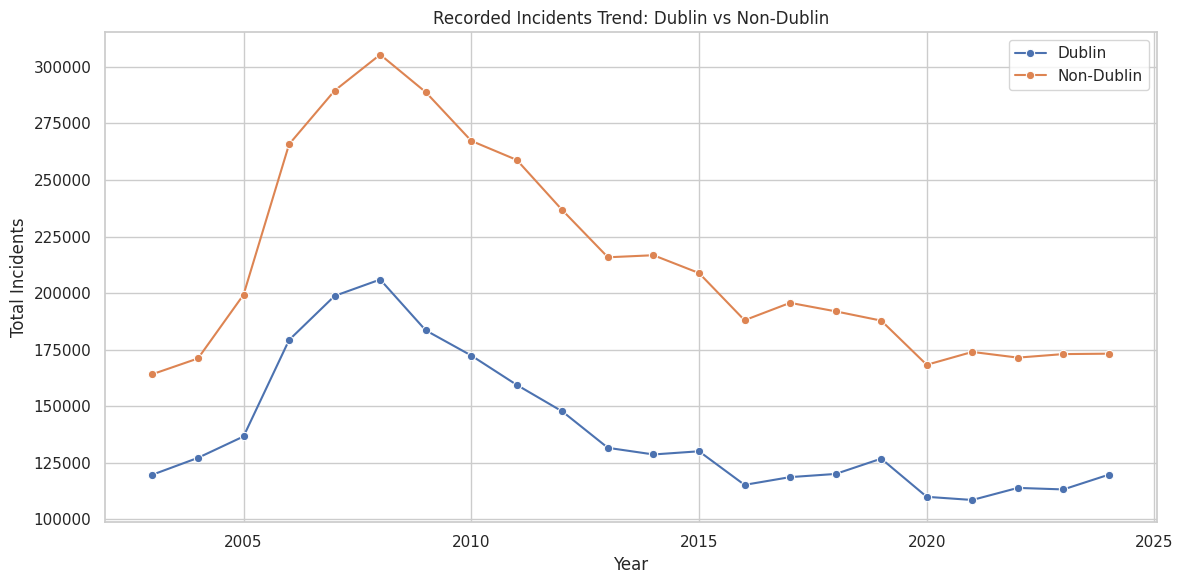

In [54]:
# Dublin vs Non-Dublin trend (all offences)

dublin_trend = (
    df.assign(is_dublin=df["county"].eq("Dublin"))
      .groupby(["year", "is_dublin"], as_index=False)["incidents"]
      .sum()
      .pivot(index="year", columns="is_dublin", values="incidents")
      .rename(columns={False: "Non-Dublin", True: "Dublin"})
      .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=dublin_trend, x="year", y="Dublin", marker="o", label="Dublin")
sns.lineplot(data=dublin_trend, x="year", y="Non-Dublin", marker="o", label="Non-Dublin")
plt.title("Recorded Incidents Trend: Dublin vs Non-Dublin")
plt.xlabel("Year")
plt.ylabel("Total Incidents")
plt.tight_layout()
plt.show()

A simple national split confirms that non-Dublin incident volumes exceed Dublin each year, but both series follow the same broad pattern: a sharp rise into the late-2000s peak, followed by a sustained decline and then stabilisation in the early-2020s. This supports the earlier concentration finding: while Dublin is a major contributor, Ireland’s recorded crime burden is still structurally distributed across the rest of the country and requires multi-region planning rather than a Dublin-only lens.

In [55]:
# Top 3 offence groups for top 10 counties by total incidents

top_counties = (
    df.groupby("county", as_index=False)["incidents"]
      .sum()
      .sort_values("incidents", ascending=False)
      .head(10)["county"]
      .tolist()
)

top_offence_by_county = (
    df[df["county"].isin(top_counties)]
    .groupby(["county", "offence_group_name"], as_index=False)["incidents"]
    .sum()
    .sort_values(["county", "incidents"], ascending=[True, False])
    .groupby("county")
    .head(3)
)

display(top_offence_by_county)

,county,offence_group_name,incidents
10,Cork,Road and traffic offences,215230
12,Cork,Theft and related offences,124727
9,Cork,Public order and other social code offences,113100
26,Dublin,Theft and related offences,780469
24,Dublin,Road and traffic offences,716637
23,Dublin,Public order and other social code offences,308667
38,Galway,Road and traffic offences,81411
40,Galway,Theft and related offences,53610
37,Galway,Public order and other social code offences,48754
52,Kildare,Road and traffic offences,61978


### Risk Index methodology

**Formula**:  
Risk Index = 0.6 × normalised recent incidents + 0.4 × normalised growth rate  

**Why these weights?** Prioritises stations with sustained structural workload (60%) while still rewarding emerging growth signals (40%). Growth safely capped at 10x to reduce volatility from small‑base stations.

Both components use min–max normalisation across all stations for comparability.


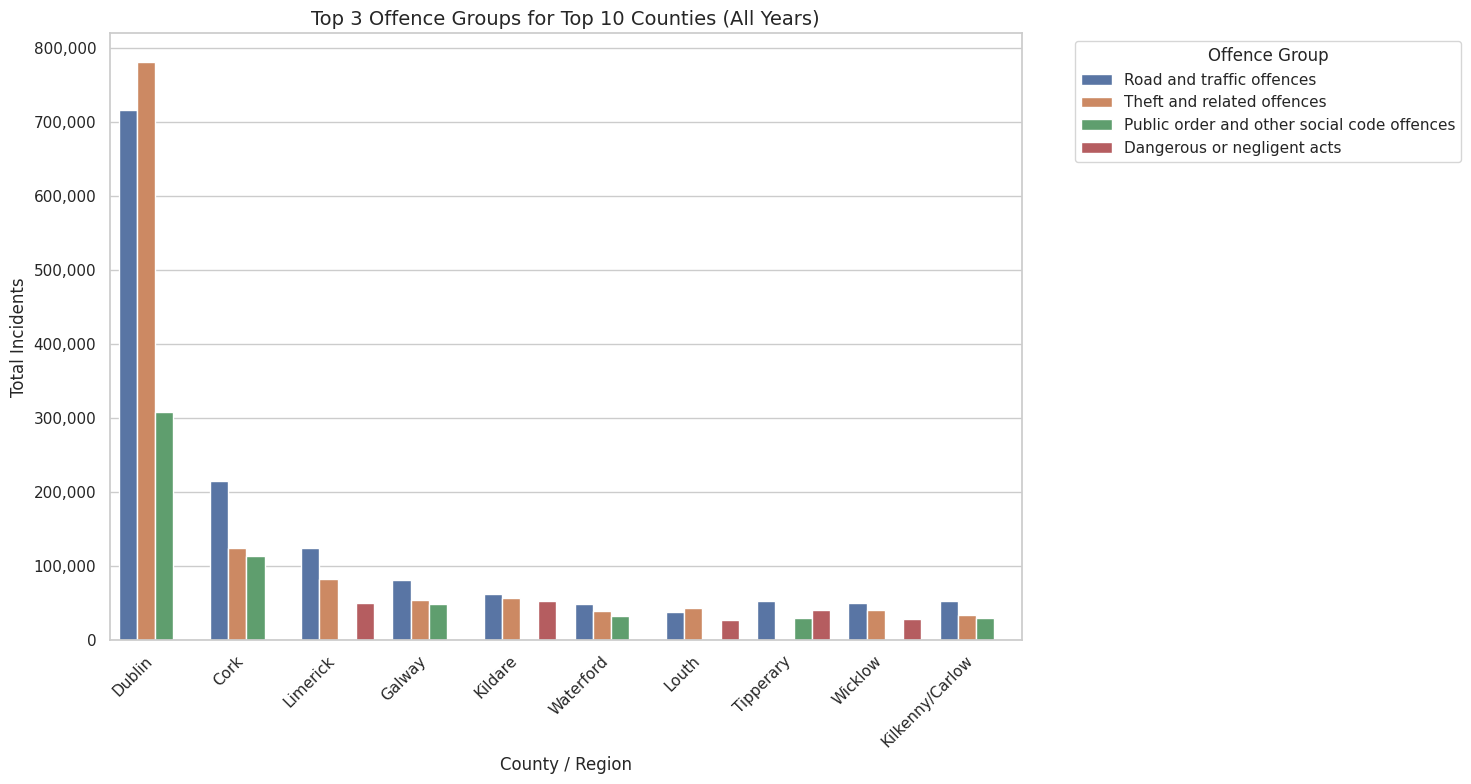

In [56]:
# Reset index for clean plotting (recommended)
top_offence_by_county = top_offence_by_county.reset_index(drop=True)

plt.figure(figsize=(15, 8))

sns.barplot(
    data=top_offence_by_county,
    x="county",
    y="incidents",
    hue="offence_group_name",
    order=top_counties  # keeps the Top-10 county ranking on the x-axis
)

plt.title("Top 3 Offence Groups for Top 10 Counties (All Years)", fontsize=14)
plt.xlabel("County / Region", fontsize=12)
plt.ylabel("Total Incidents", fontsize=12)

# Nice number formatting
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Offence Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

For the highest-volume counties, the dominant offence groups are broadly consistent. In Dublin, the largest contributors are Theft and related offences and Road and traffic offences, followed by Public order. The same two categories recur across other high-volume counties (e.g., Cork, Galway, Limerick, Kildare, Waterford, Wicklow), with some counties showing Dangerous or negligent acts as a third key driver. This reinforces that station-level prioritisation should be paired with offence-type targeting, because the “risk” is not just where volume is high, but also what crime mix is driving operational demand.

In [57]:
# Workload proxy: incidents per station (county-level)
stations_per_county = (
    df[["station_code", "county"]]
      .drop_duplicates()
      .groupby("county", as_index=False)["station_code"]
      .nunique()
      .rename(columns={"station_code": "n_stations"})
)

county_totals = (
    df.groupby("county", as_index=False)["incidents"]
      .sum()
      .sort_values("incidents", ascending=False)
)

county_workload = county_totals.merge(stations_per_county, on="county", how="left")
county_workload["incidents_per_station"] = county_workload["incidents"] / county_workload["n_stations"]

display(
    county_workload.sort_values("incidents_per_station", ascending=False).head(10)
)

,county,incidents,n_stations,incidents_per_station
0,Dublin,3067279,41,74811.682927
4,Kildare,291815,15,19454.333333
6,Louth,214431,13,16494.692308
2,Limerick,432494,29,14913.586207
8,Wicklow,213663,17,12568.411765
12,Meath,190208,16,11888.000000
5,Waterford,221666,19,11666.631579
17,Westmeath,144698,13,11130.615385
1,Cork,759886,72,10553.972222
16,Clare,166912,17,9818.352941


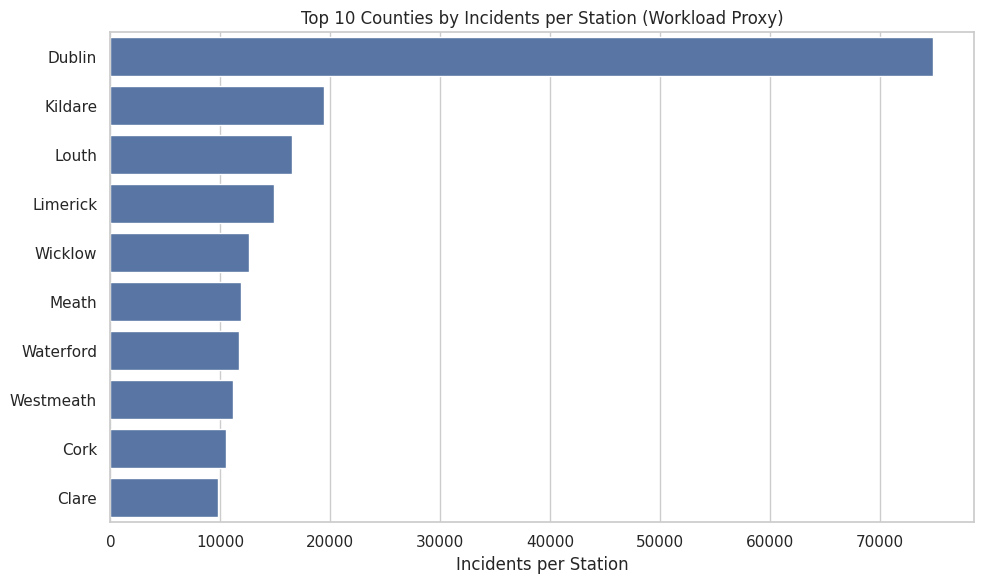

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=county_workload.sort_values("incidents_per_station", ascending=False).head(10),
    x="incidents_per_station",
    y="county"
)
plt.title("Top 10 Counties by Incidents per Station (Workload Proxy)")
plt.xlabel("Incidents per Station")
plt.ylabel("")
plt.tight_layout()
plt.show()

To better understand operational pressure beyond raw totals, a workload proxy was calculated by dividing total recorded incidents in each county by the number of Garda stations within that county. While this is not a population-adjusted crime rate, it provides a useful approximation of incident concentration relative to station coverage.

Dublin stands out significantly, with approximately 3.07 million incidents across 41 stations, resulting in roughly 74,812 incidents per station — far exceeding all other counties. This reflects the structural concentration of policing demand in the capital region.

Outside Dublin, Kildare, Louth, and Limerick show the next highest workload per station, indicating relatively high incident concentration compared to their station counts. In contrast, counties such as Cork, despite having high total incident volumes, show lower incidents per station due to a larger distribution of stations (72), suggesting a more dispersed operational load.

Overall, this proxy highlights where incident demand is most concentrated per station and provides additional context for station-level risk prioritisation.

In [59]:
print("Stations in risk ranking:", station_risk["station_code"].nunique())
print("Recent period total incidents:", station_risk["incidents_recent"].sum())
print("Historical period total incidents:", station_risk["incidents_hist"].sum())

Stations in risk ranking: 564
Recent period total incidents: 1425510
Historical period total incidents: 1583285


In [60]:
from google.colab import files

top20_risk.to_csv("station_risk_metrics.csv", index=False)

# Optional: full station table
station_risk.sort_values("risk_index", ascending=False).to_csv("station_risk_metrics_full.csv", index=False)
risk_df.to_csv('station_offence_metrics.csv', index=False)
print("Saved: station_risk_metrics.csv, station_risk_metrics_full.csv and station_offence_metrics.csv")

files.download("station_risk_metrics.csv")
files.download("station_risk_metrics_full.csv")
files.download("station_offence_metrics.csv")

Saved: station_risk_metrics.csv, station_risk_metrics_full.csv and station_offence_metrics.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Limitations & Next Steps
Key limitations:

Recorded incidents reflect reporting/recording practices, not necessarily true crime volume.

No population or Garda staffing data, so this is workload proxy only (not per-capita risk).

Assumes equal "cost" across offence types; could weight by severity/sentencing guidelines.

Next steps with more data:

Merge CSO population → per-capita rates by station catchment.

Test Risk Index sensitivity (0.6/0.4 volume/growth → sliders).

Add forecasting (ARIMA/XGBoost) → 2025–2027 risk evolution.

Deploy Streamlit dashboard with interactive maps + filters.

## Deliverables

Saved files (ready for dashboards/planning):

station_risk_metrics_full.csv: 564 stations | Risk Index, rank, growth, volume totals → File 3 clustering/SQL
​

station_offence_full.csv: 7,896 rows (564×14) | Per-station/offence hist/recent/growth → offence analysis
​

Plug directly into Power BI/Tableau/SQL. Full rankings ready for divisional briefings. 🎯
